In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")

# ========== 按 category_label 去重，每个品类保留第一条 ==========
print("\n" + "="*60)
print("🧹 按 category_label 去重，每个品类保留唯一一条")
print("="*60)

before = len(df)
df_unique_cat = df.drop_duplicates(subset=["category_label"], keep="first").reset_index(drop=True)
after = len(df_unique_cat)

print(f"去重前行数：{before:,}")
print(f"去重后行数：{after:,}")
print(f"删除重复行：{before - after:,}")
print(f"品类唯一值数量：{after:,} 个")

# ========== 展示全部唯一品类（分页） ==========
print("\n" + "="*60)
print(f"📋 全部 {after} 个唯一品类列表")
print("="*60)

cat_list = sorted(df_unique_cat["category_label"].tolist())
page_size = 30
total_pages = (len(cat_list) + page_size - 1) // page_size

for i in range(0, len(cat_list), page_size):
    page = cat_list[i:i+page_size]
    page_num = i // page_size + 1
    print(f"\n--- 第 {page_num}/{total_pages} 页（第 {i+1}-{min(i+page_size, len(cat_list))} 个）---")
    for j, cat in enumerate(page, i+1):
        print(f"  {j:>4}. {cat}")

# ========== 导出唯一品类数据 ==========
output_file = f"{base_path}\\品类唯一值_每条保留一条.csv"
df_unique_cat.to_csv(output_file, index=False, encoding="utf-8-sig")

# 同时导出纯品类名列表
cat_only_file = f"{base_path}\\品类唯一值名称列表.csv"
pd.DataFrame({"category_label": cat_list}).to_csv(cat_only_file, index=False, encoding="utf-8-sig")

print("\n" + "="*60)
print("✅ 完成！输出文件：")
print("="*60)
print(f"  1. 品类唯一值_每条保留一条.csv   —— 每个品类完整一条记录（含所有字段）")
print(f"  2. 品类唯一值名称列表.csv        —— 纯品类名列表（仅 category_label 列）")

📥 读取成功，总行数：755,536

🧹 按 category_label 去重，每个品类保留唯一一条
去重前行数：755,536
去重后行数：1,021
删除重复行：754,515
品类唯一值数量：1,021 个

📋 全部 1021 个唯一品类列表

--- 第 1/35 页（第 1-30 个）---
     1. DIY手工材料包
     2. DIY手工材料包（串珠款）
     3. DIY手工材料包（刺绣款）
     4. DIY拼图套装
     5. DIY拼图套装（3D立体）
     6. DIY拼图套装（立体建筑款）
     7. HDMI高清线
     8. HDMI高清线（2米款）
     9. HDMI高清线（镀金款）
    10. LED台灯
    11. LED台灯（折叠款）
    12. LED台灯（护眼款）
    13. LED台灯（触摸款）
    14. Lightning转接头
    15. Lightning转接头（二合一款）
    16. Lightning转接头（镀金款）
    17. SD存储卡（256GB款）
    18. SD存储卡（512GB款）
    19. SD存储卡（64GB/128GB）
    20. Type-C转接头
    21. Type-C转接头（弯头款）
    22. Type-C转接头（铝合金款）
    23. USB分线器
    24. USB分线器（4口款）
    25. USB分线器（多接口款）
    26. USB加湿器（小型）
    27. USB加湿器（静音款）
    28. USB加湿器（香薰款）
    29. USB声卡
    30. USB声卡（外置款）

--- 第 2/35 页（第 31-60 个）---
    31. USB声卡（独立芯片款）
    32. USB风扇
    33. U盘（128GB款）
    34. U盘（256GB款）
    35. U盘（32GB/64GB）
    36. VGA转HDMI转换器
    37. VGA转HDMI转换器（4K支持款）
    38. VGA转HDMI转换器（带音频款）
    39. VR眼镜（4K分辨率款）
    40. VR眼镜（入门款）
  

In [2]:
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")
print(f"原始品类数：{df['category_label'].nunique()}")

# ========== 一级大类分类函数 ==========
def classify_big_category(label):
    label = str(label).strip()
    # 去掉括号内容，匹配基础品类名
    base = re.sub(r'[（(].*?[)）]', '', label).strip()
    
    # ===== 数码配件 =====
    if any(k in base for k in [
        "手机壳","数据线","USB风扇","耳机","台灯","充电器","鼠标","键盘",
        "U盘","HDMI高清线","SD存储卡","Type-C转接头","Lightning转接头",
        "USB分线器","USB声卡","USB加湿器","VGA转HDMI转换器","VR眼镜",
        "便携式WiFi热点","便携式屏幕清洁器","便携式电源逆变器",
        "充电线收纳盒","多功能读卡器","太阳能充电宝","平板保护套",
        "平板支架","录音笔","手机K歌","手机三脚架","手机信号增强器",
        "手机屏幕放大器","手机支架","手机背夹电池","手机镜头套装","手机防水袋",
        "数码相框","声控音响","无线充电器支架","无线充电板","无线网卡",
        "无线耳机挂绳","无线耳机","无线蓝牙音箱","无线路由器","移动电源",
        "移动硬盘","蓝牙音箱","蓝牙耳机","迷你蓝牙音箱","迷你麦克风",
        "降噪耳机","降噪耳塞","水晶头","网线钳","屏幕清洁套装",
        "电脑屏幕挂灯","电脑摄像头","电竞耳机支架","电竞键盘","游戏手柄",
        "游戏方向盘","游戏耳机","游戏鼠标","游戏座椅垫","键盘防尘罩",
        "鼠标垫","手写笔","激光笔","电子翻译器","电子计算器","电子闹钟",
        "电子书阅读器","无人机","行车记录仪","车载充电器","车载手机支架",
        "汽车空气净化器","相机清洁套装","自拍杆","自拍补光灯",
        "笔记本散热支架","笔记本电脑包","笔记本电脑支架","LED台灯",
        "折叠书桌灯","小型投影仪","手持小风扇","桌面风扇","智能插座",
        "智能插座定时器","智能灯泡","智能夜灯","小夜灯"
    ]):
        return "数码配件"
    
    # ===== 文具办公 =====
    elif any(k in base for k in [
        "笔记本","文件夹","中性笔","回形针","胶带","便利贴","书签",
        "学生尺子","学生计算器","彩色便签条","彩色荧光笔","彩色铅笔",
        "创意橡皮","剪刀","手工剪刀","多功能文具盒","字帖练习本",
        "数学练习册","文件收纳袋","文具收纳架","活页本","橡皮擦",
        "毛笔","水彩颜料套装","白板笔","纸胶带","订书机","订书钉",
        "自动铅笔","英语单词卡片","钢尺","阅读架","透明文件袋",
        "手绘模板","手账胶带","修正带","简易画板","画架","相册",
        "小型白板","白板","磁性书签"
    ]):
        return "文具办公"
    
    # ===== 美妆个护 =====
    elif any(k in base for k in [
        "指甲油","化妆刷","化妆棉","化妆镜","口红","唇膜","卸妆水",
        "发圈","发夹","发带","发泥","发蜡","修容棒","假睫毛",
        "护手霜","指甲剪套装","指甲锉","眉笔","眼线笔","睫毛增长液",
        "睫毛夹","睫毛滋养液","睫毛膏","粉底液","美妆蛋","美妆收纳盒",
        "美容放大镜","美容面膜刷","美甲UV胶","美甲亮片","美甲工具套装",
        "美甲灯","美甲贴纸","美甲贴钻","美白精华","腮红","高光粉",
        "隔离霜","面膜","面部按摩仪","面部清洁仪","防晒喷雾","香体喷雾",
        "香皂","香薰精油套装","香薰蜡烛","染发工具","定型喷雾","定妆喷雾",
        "梳子","化妆刷清洗剂","瑜伽眼罩","运动发带","运动头带",
        "零钱包","卡包","戒指","手链","耳钉","围巾","太阳镜"
    ]):
        return "美妆个护"
    
    # ===== 家居日用 =====
    elif any(k in base for k in [
        "衣架","垃圾桶","收纳盒","保温杯","杯子","桌布","晾衣架",
        "小型垃圾桶","小型工具箱","小型盆栽","小型镜子","创意摆件",
        "干燥剂","弹力带","挂饰","晒衣夹","智能保温杯","智能水杯",
        "浴室地垫","清洁刷","洗衣袋","防潮袋","鞋刷","鞋垫","餐具套装",
        "厨房开瓶器","火柴盒","空气清新剂","毛巾","手套","围巾",
        "仿真花","小型玩偶","手提袋","折叠伞","折叠水壶","护膝",
        "桌面收纳架","桌面整理盘","桌面吸尘器","桌面加湿器",
        "镜子","收纳","拖把"
    ]):
        return "家居日用"
    
    # ===== 食品茶饮 =====
    elif any(k in base for k in [
        "茶包","零食礼包","方便面","速溶咖啡"
    ]):
        return "食品茶饮"
    
    # ===== 运动健身 =====
    elif any(k in base for k in [
        "健身垫","健身手套","健身拉力绳","健身计步器","健身课程体验券",
        "小型哑铃","弹力带","瑜伽垫","瑜伽眼罩","瑜伽砖","瑜伽袜",
        "跳绳","跑步腰包","运动内衣","运动发带","运动头带","运动护腕",
        "运动护踝","运动毛巾","运动水壶","运动背包","短跑训练鞋",
        "跳舞鞋","乒乓球拍套装","网球拍","羽毛球拍","防滑瑜伽垫",
        "简易瑜伽垫","护膝"
    ]):
        return "运动健身"
    
    # ===== 智能家居 =====
    elif any(k in base for k in [
        "智能体重秤","智能保温杯","智能健康手环","智能夜灯","智能家居控制器",
        "智能手写板","智能手环","智能手表表带","智能扫地机器人","智能插座",
        "智能插座定时器","智能水杯","智能灯泡","智能睡眠眼罩","智能窗帘控制器",
        "智能语音助手","智能追踪器","智能遥控器","智能门铃","体脂检测仪",
        "电子称重勺","电子厨房计时器","电子显微镜","电子节拍器"
    ]):
        return "智能家居"
    
    # ===== 游戏文娱 =====
    elif any(k in base for k in [
        "游戏手柄","游戏方向盘","游戏耳机","游戏鼠标","游戏座椅垫",
        "电竞耳机支架","电竞键盘","VR眼镜","无人机","桌游卡牌",
        "DIY拼图套装","儿童拼图","拼图","科学实验工具套装"
    ]):
        return "游戏文娱"
    
    # ===== 宠物用品 =====
    elif any(k in base for k in [
        "宠物喂食器","宠物玩具","猫抓板"
    ]):
        return "宠物用品"
    
    # ===== 汽车用品 =====
    elif any(k in base for k in [
        "车载充电器","车载手机支架","行车记录仪","汽车空气净化器"
    ]):
        return "汽车用品"
    
    # ===== 手工DIY =====
    elif any(k in base for k in [
        "DIY手工材料包","DIY拼图套装","手工剪刀","手绘模板","手账胶带"
    ]):
        return "手工DIY"
    
    # ===== 服饰配饰 =====
    elif any(k in base for k in [
        "袜子","手套","围巾","发圈","发夹","发带","戒指","手链",
        "耳钉","卡包","零钱包","太阳镜","运动内衣","运动发带",
        "运动头带","运动护腕","运动护踝","运动毛巾","运动水壶",
        "运动背包","跳舞鞋","短跑训练鞋","手提袋"
    ]):
        return "服饰配饰"
    
    # ===== 收纳整理 =====
    elif any(k in base for k in [
        "收纳盒","桌面收纳架","桌面整理盘","文件收纳袋","文具收纳架",
        "充电线收纳盒","美妆收纳盒","耳机收纳盒","多功能文具盒"
    ]):
        return "收纳整理"
    
    # ===== 厨房用品 =====
    elif any(k in base for k in [
        "厨房开瓶器","餐具套装","保温杯","杯子","电蚊拍"
    ]):
        return "厨房用品"
    
    # ===== 清洁用品 =====
    elif any(k in base for k in [
        "屏幕清洁套装","便携式屏幕清洁器","清洁刷","洗衣袋","浴室地垫",
        "鞋刷","干燥剂","防潮袋"
    ]):
        return "清洁用品"
    
    # ===== 摄影摄像 =====
    elif any(k in base for k in [
        "相机清洁套装","手机镜头套装","自拍杆","自拍补光灯","三脚架"
    ]):
        return "摄影摄像"
    
    # ===== 图书教育 =====
    elif any(k in base for k in [
        "字帖练习本","数学练习册","英语单词卡片","学生尺子","学生计算器",
        "电子书阅读器","电子翻译器"
    ]):
        return "图书教育"
    
    # ===== 个护清洁 =====
    elif any(k in base for k in [
        "牙刷","牙膏","洗手液","小型剃须刀","指甲剪套装","指甲锉",
        "旅行牙刷套装"
    ]):
        return "个护清洁"
    
    # ===== 其他 =====
    else:
        return "其他"

# ========== 新增「大类」列 ==========
df["大类"] = df["category_label"].apply(classify_big_category)

# ========== 统计结果 ==========
print("\n" + "="*60)
print("📊 大类分类统计")
print("="*60)

big_cat_count = df.groupby("大类").agg(
    品类数=("category_label", "nunique"),
    记录数=("user_id", "count")
).reset_index()
big_cat_count = big_cat_count.sort_values("记录数", ascending=False).reset_index(drop=True)
big_cat_count["记录占比%"] = round(big_cat_count["记录数"] / len(df) * 100, 2)

print(big_cat_count.to_string(index=False))

# 检查"其他"类
other_cats = df[df["大类"] == "其他"]["category_label"].unique()
print(f"\n⚠️  归为「其他」的品类：{len(other_cats)} 个")
if len(other_cats) > 0:
    print("其他类品类列表：")
    for c in sorted(other_cats):
        print(f"  - {c}")

# ========== 保存文件 ==========
output_file = f"{base_path}\\三表合并完整数据_带大类.csv"
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\n" + "="*60)
print(f"✅ 完成！已新增「大类」列")
print(f"📄 输出文件：{output_file}")
print(f"📊 共 {df['大类'].nunique()} 个一级大类")
print("="*60)

📥 读取成功，总行数：755,536
原始品类数：1021

📊 大类分类统计
   大类  品类数    记录数  记录占比%
 数码配件  286 245432  32.48
 家居日用  159 131055  17.35
 美妆个护  214 124462  16.47
 文具办公  142 110445  14.62
 运动健身   71  32813   4.34
 个护清洁   20  29580   3.92
 食品茶饮   16  25219   3.34
 智能家居   54  13406   1.77
 宠物用品   12  12643   1.67
   其他   22  11887   1.57
 游戏文娱   14   9322   1.23
 服饰配饰    4   5136   0.68
 厨房用品    4   2844   0.38
手工DIY    3   1292   0.17

⚠️  归为「其他」的品类：22 个
其他类品类列表：
  - 插座延长线
  - 插座延长线（多孔款）
  - 插座延长线（带开关）
  - 插座延长线（防雷款）
  - 电动螺丝刀（多功能款）
  - 电动螺丝刀（小型）
  - 电动螺丝刀（锂电款）
  - 笔袋
  - 笔袋（帆布款）
  - 笔袋（网格款）
  - 蚊香
  - 蚊香（无烟款）
  - 蚊香（电热款）
  - 蚊香（驱蚊液款）
  - 贴纸
  - 贴纸（夜光款）
  - 贴纸（镭射款）
  - 贴纸（防水款）
  - 钥匙扣
  - 钥匙扣（卡通款）
  - 钥匙扣（钥匙圈款）
  - 钥匙扣（钥匙灯款）

✅ 完成！已新增「大类」列
📄 输出文件：C:\Users\ASUS\Downloads\dk\三表合并完整数据_带大类.csv
📊 共 14 个一级大类


📥 读取成功，总行数：755,536
大类数量：14

📊 按大类聚合销量
总购买订单数：13,346

==== 各大类销量明细 ====
   大类   销量  销量占比%     累计占比  品类商品数
 数码配件 3249  24.34 0.243444     45
 美妆个护 2534  18.99 0.433313      8
 家居日用 2493  18.68 0.620111    130
 文具办公 2115  15.85 0.778585     46
 运动健身  785   5.88 0.837404   1393
 食品茶饮  521   3.90 0.876442   2094
 智能家居  408   3.06 0.907013    177
 个护清洁  348   2.61 0.933089   3140
 游戏文娱  324   2.43 0.957366   1947
   其他  242   1.81 0.975498     86
 宠物用品  195   1.46 0.990109   1622
 服饰配饰   77   0.58 0.995879   1578
 厨房用品   32   0.24 0.998277    899
手工DIY   23   0.17 1.000000     65

✅ 销量明细已保存：业务品类销量明细.csv

🎨 生成子图组合大图
✅ 组合大图已保存：业务大类分析总览_四图合一.png


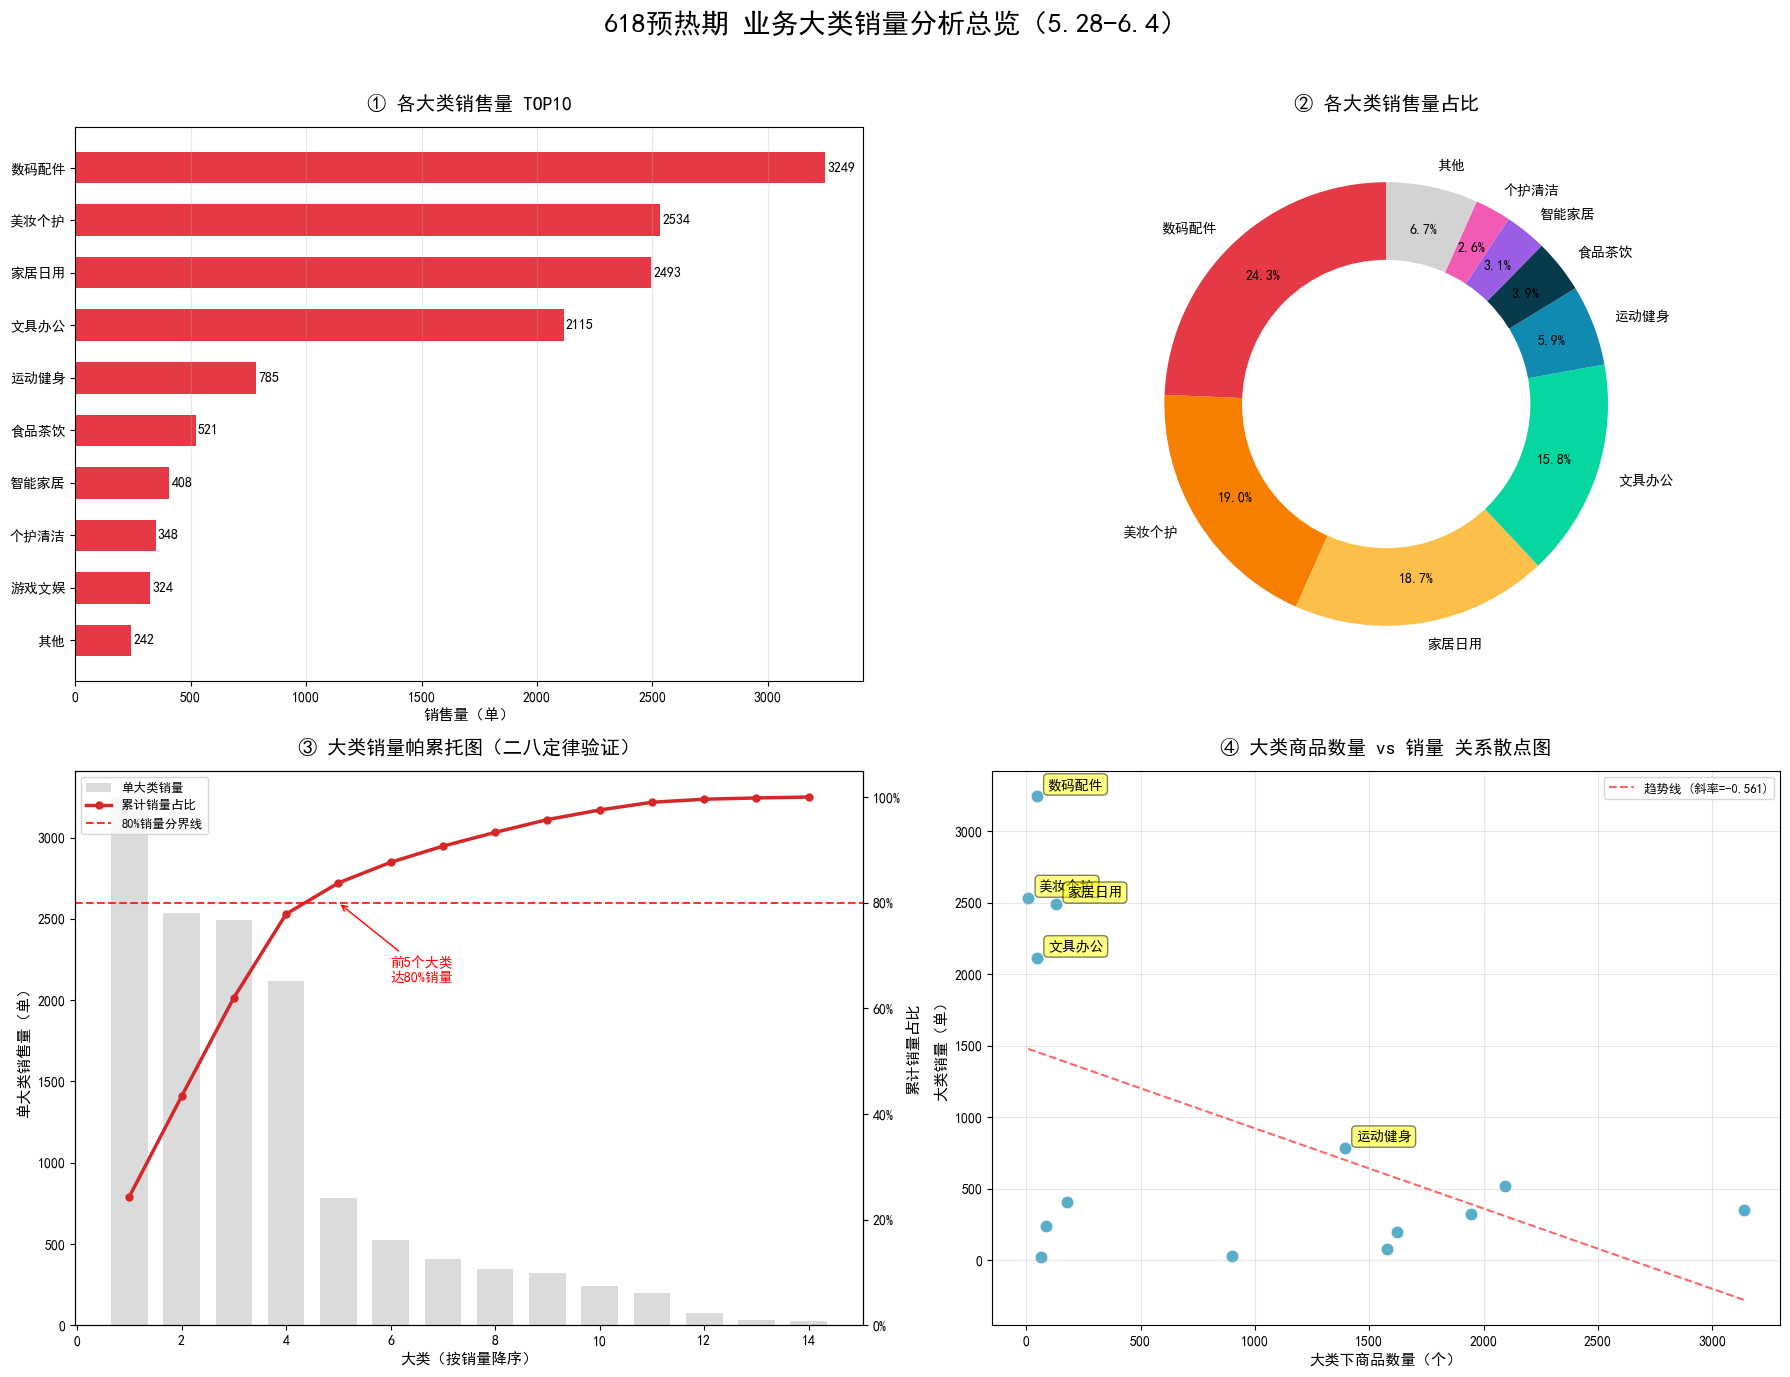


🖼️  单独保存各张图
✅ 图1已保存：业务品类TOP10.png
✅ 图2已保存：业务品类占比饼图.png
✅ 图3已保存：业务品类帕累托图.png
✅ 图4已保存：商品规模vs销量散点.png

📋 关键分析结论

总购买订单：13,346
大类总数：14
TOP1大类：数码配件，销量 3249 单，占比 24.34%
TOP3大类总销量占比：62.01%
TOP5大类总销量占比：83.74%
覆盖80%销量需要前 5 个大类，占全部大类的 35.71%

⚠️  不完全符合二八定律：需要35.7%的大类才覆盖80%销量，长尾更明显
商品数量与销量的相关系数：-0.510
  → 弱相关：商品数不是销量的决定性因素

🎉 全部完成！输出文件清单：

📦 CSV文件：
  1. 业务品类销量明细.csv          —— 各大类销量、占比、累计占比、商品数

🖼️  图片文件：
  2. 业务大类分析总览_四图合一.png  —— 4张图组合在一张大图里（子图形式）
  3. 业务品类TOP10.png             —— 单独TOP10柱状图
  4. 业务品类占比饼图.png           —— 单独饼图
  5. 业务品类帕累托图.png           —— 单独帕累托图
  6. 商品规模vs销量散点.png         —— 单独散点图



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据_带大类.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")
print(f"大类数量：{df['大类'].nunique()}")

# ============================================================
# 第一部分：按大类聚合销量数据
# ============================================================
print("\n" + "="*60)
print("📊 按大类聚合销量")
print("="*60)

# 只取购买行为
df_buy = df[df["behavior"] == "buy"].reset_index(drop=True)
total_buy = len(df_buy)
print(f"总购买订单数：{total_buy:,}")

# 按大类聚合：销量 + 品类商品数
cat_sales = df_buy.groupby("大类").agg(
    销量=("user_id", "count"),
    品类商品数=("品类商品数", "first")
).reset_index()
cat_sales = cat_sales.sort_values("销量", ascending=False).reset_index(drop=True)
cat_sales["销量占比%"] = round(cat_sales["销量"] / total_buy * 100, 2)
cat_sales["累计销量"] = cat_sales["销量"].cumsum()
cat_sales["累计占比"] = cat_sales["累计销量"] / total_buy

print(f"\n==== 各大类销量明细 ====")
print(cat_sales[["大类", "销量", "销量占比%", "累计占比", "品类商品数"]].to_string(index=False))

# 保存销量明细csv
sales_csv = f"{base_path}\\业务品类销量明细.csv"
cat_sales.to_csv(sales_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ 销量明细已保存：业务品类销量明细.csv")

# ============================================================
# 第二部分：4张子图组合大图（2行2列）
# ============================================================
print("\n" + "="*60)
print("🎨 生成子图组合大图")
print("="*60)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('618预热期 业务大类销量分析总览（5.28-6.4）', fontsize=20, fontweight='bold', y=0.98)

# ---------- 子图1：大类销量TOP10 横向柱状图 ----------
ax1 = plt.subplot(2, 2, 1)
top10 = cat_sales.head(10)
bars = ax1.barh(top10["大类"][::-1], top10["销量"][::-1], color='#E63946', height=0.6)
ax1.set_title('① 各大类销售量 TOP10', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('销售量（单）', fontsize=11)
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}', ha='left', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# ---------- 子图2：大类销量占比饼图 ----------
ax2 = plt.subplot(2, 2, 2)
# TOP8 + 其他
top_n = 8
cat_top = cat_sales.head(top_n).copy()
others_sales = cat_sales["销量"][top_n:].sum()
pie_data = pd.concat([
    cat_top[["大类", "销量"]],
    pd.DataFrame({"大类": ["其他"], "销量": [others_sales]})
], ignore_index=True)

colors = ['#E63946', '#F77F00', '#FCBF49', '#06D6A0', '#118AB2',
          '#073B4C', '#9B5DE5', '#F15BB5', '#D3D3D3']
wedges, texts, autotexts = ax2.pie(
    pie_data["销量"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.8,
    textprops={'fontsize': 10}
)
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('② 各大类销售量占比', fontsize=14, fontweight='bold', pad=12)

# ---------- 子图3：帕累托图 ----------
ax3 = plt.subplot(2, 2, 3)
ax3_twin = ax3.twinx()

cat_sales_sorted = cat_sales.reset_index(drop=True)
cat_sales_sorted["大类序号"] = range(1, len(cat_sales_sorted)+1)

ax3.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销量"], 
        color='#cccccc', alpha=0.7, label='单大类销量', width=0.7)
ax3_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"], 
              color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销量占比')
ax3_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')

ax3.set_xlabel('大类（按销量降序）', fontsize=11)
ax3.set_ylabel('单大类销售量（单）', fontsize=11)
ax3_twin.set_ylabel('累计销量占比', fontsize=11)
ax3_twin.set_ylim(0, 1.05)
ax3_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3.set_title('③ 大类销量帕累托图（二八定律验证）', fontsize=14, fontweight='bold', pad=12)

# 标注80%线对应的大类数
eight_pct_idx = cat_sales_sorted[cat_sales_sorted["累计占比"] >= 0.8].iloc[0]["大类序号"]
ax3_twin.annotate(f'前{int(eight_pct_idx)}个大类\n达80%销量',
                  xy=(eight_pct_idx, 0.8),
                  xytext=(eight_pct_idx+1, 0.65),
                  fontsize=10, color='red',
                  arrowprops=dict(arrowstyle='->', color='red'))

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ---------- 子图4：品类商品数 vs 销量 散点图 ----------
ax4 = plt.subplot(2, 2, 4)
scatter_data = cat_sales[(cat_sales["品类商品数"] > 0) & (cat_sales["销量"] > 0)]

scatter = ax4.scatter(scatter_data["品类商品数"], scatter_data["销量"],
                      alpha=0.7, s=80, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4.set_xlabel('大类下商品数量（个）', fontsize=11)
ax4.set_ylabel('大类销量（单）', fontsize=11)
ax4.set_title('④ 大类商品数量 vs 销量 关系散点图', fontsize=14, fontweight='bold', pad=12)
ax4.grid(True, alpha=0.3)

# 标注TOP5销量的大类名称
top5 = scatter_data.sort_values("销量", ascending=False).head(5)
for _, row in top5.iterrows():
    ax4.annotate(row["大类"],
                 (row["品类商品数"], row["销量"]),
                 xytext=(8, 5), textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 添加趋势线
z = np.polyfit(scatter_data["品类商品数"], scatter_data["销量"], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4.plot(x_line, p(x_line), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z[0]:.3f})')
ax4.legend(fontsize=9)

# ---------- 调整布局 ----------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 保存组合大图
combined_png = f"{base_path}\\业务大类分析总览_四图合一.png"
plt.savefig(combined_png, dpi=200, bbox_inches='tight')
print(f"✅ 组合大图已保存：业务大类分析总览_四图合一.png")
plt.show()

# ============================================================
# 第三部分：单独保存每张图（可选）
# ============================================================
print("\n" + "="*60)
print("🖼️  单独保存各张图")
print("="*60)

# 单独保存TOP10图
fig1, ax1_single = plt.subplots(figsize=(12, 6))
bars1 = ax1_single.barh(top10["大类"][::-1], top10["销量"][::-1], color='#E63946', height=0.6)
ax1_single.set_title('业务大类销售量 TOP10（618预热期 5.28-6.4）', fontsize=16, fontweight='bold')
ax1_single.set_xlabel('销售量（单）', fontsize=12)
for bar in bars1:
    width = bar.get_width()
    ax1_single.text(width + 10, bar.get_y() + bar.get_height()/2.,
                    f'{int(width)}', ha='left', va='center', fontsize=11)
ax1_single.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类TOP10.png", dpi=150, bbox_inches='tight')
print("✅ 图1已保存：业务品类TOP10.png")
plt.close()

# 单独保存饼图
fig2, ax2_single = plt.subplots(figsize=(10, 10))
wedges2, texts2, autotexts2 = ax2_single.pie(
    pie_data["销量"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    textprops={'fontsize': 12}
)
centre_circle2 = plt.Circle((0, 0), 0.70, fc='white')
ax2_single.add_artist(centre_circle2)
ax2_single.set_title('各大类销售量占比', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类占比饼图.png", dpi=150, bbox_inches='tight')
print("✅ 图2已保存：业务品类占比饼图.png")
plt.close()

# 单独保存帕累托图
fig3, ax3_single = plt.subplots(figsize=(14, 7))
ax3_single_twin = ax3_single.twinx()
ax3_single.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销量"], 
               color='#cccccc', alpha=0.7, label='单大类销量', width=0.7)
ax3_single_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"], 
                     color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销量占比')
ax3_single_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')
ax3_single.set_xlabel('大类（按销量降序排列）', fontsize=12)
ax3_single.set_ylabel('单大类销售量（单）', fontsize=12)
ax3_single_twin.set_ylabel('累计销量占比', fontsize=12)
ax3_single_twin.set_ylim(0, 1.05)
ax3_single_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_single_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3_single.set_title('业务大类销量帕累托图（长尾分布分析）', fontsize=16, fontweight='bold')
lines3, labels3 = ax3_single.get_legend_handles_labels()
lines4, labels4 = ax3_single_twin.get_legend_handles_labels()
ax3_single.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类帕累托图.png", dpi=150, bbox_inches='tight')
print("✅ 图3已保存：业务品类帕累托图.png")
plt.close()

# 单独保存散点图
fig4, ax4_single = plt.subplots(figsize=(12, 7))
scatter4 = ax4_single.scatter(scatter_data["品类商品数"], scatter_data["销量"],
                              alpha=0.7, s=100, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4_single.set_xlabel('大类下商品数量（个）', fontsize=12)
ax4_single.set_ylabel('大类销量（单）', fontsize=12)
ax4_single.set_title('大类商品数量 vs 销量 关系散点图', fontsize=16, fontweight='bold')
ax4_single.grid(True, alpha=0.3)
top5_4 = scatter_data.sort_values("销量", ascending=False).head(5)
for _, row in top5_4.iterrows():
    ax4_single.annotate(row["大类"],
                        (row["品类商品数"], row["销量"]),
                        xytext=(8, 5), textcoords='offset points', fontsize=11,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
z4 = np.polyfit(scatter_data["品类商品数"], scatter_data["销量"], 1)
p4 = np.poly1d(z4)
x_line4 = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4_single.plot(x_line4, p4(x_line4), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z4[0]:.3f})')
ax4_single.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\商品规模vs销量散点.png", dpi=150, bbox_inches='tight')
print("✅ 图4已保存：商品规模vs销量散点.png")
plt.close()

# ============================================================
# 第四部分：关键结论输出
# ============================================================
print("\n" + "="*60)
print("📋 关键分析结论")
print("="*60)

print(f"\n总购买订单：{total_buy:,}")
print(f"大类总数：{len(cat_sales)}")
print(f"TOP1大类：{cat_sales.iloc[0]['大类']}，销量 {cat_sales.iloc[0]['销量']} 单，占比 {cat_sales.iloc[0]['销量占比%']}%")
print(f"TOP3大类总销量占比：{cat_sales.head(3)['销量占比%'].sum():.2f}%")
print(f"TOP5大类总销量占比：{cat_sales.head(5)['销量占比%'].sum():.2f}%")
print(f"覆盖80%销量需要前 {int(eight_pct_idx)} 个大类，占全部大类的 {eight_pct_idx/len(cat_sales)*100:.2f}%")

# 二八定律判断
if eight_pct_idx / len(cat_sales) <= 0.25:
    print(f"\n✅ 基本符合二八定律：前{eight_pct_idx/len(cat_sales)*100:.1f}%的大类贡献80%销量")
else:
    print(f"\n⚠️  不完全符合二八定律：需要{eight_pct_idx/len(cat_sales)*100:.1f}%的大类才覆盖80%销量，长尾更明显")

# 商品数vs销量相关性
corr = scatter_data["品类商品数"].corr(scatter_data["销量"])
print(f"商品数量与销量的相关系数：{corr:.3f}")
if corr > 0.7:
    print("  → 强正相关：商品越多销量越高")
elif corr > 0.4:
    print("  → 中等正相关：商品数对销量有一定影响")
else:
    print("  → 弱相关：商品数不是销量的决定性因素")

print("\n" + "="*60)
print("🎉 全部完成！输出文件清单：")
print("="*60)
print("""
📦 CSV文件：
  1. 业务品类销量明细.csv          —— 各大类销量、占比、累计占比、商品数

🖼️  图片文件：
  2. 业务大类分析总览_四图合一.png  —— 4张图组合在一张大图里（子图形式）
  3. 业务品类TOP10.png             —— 单独TOP10柱状图
  4. 业务品类占比饼图.png           —— 单独饼图
  5. 业务品类帕累托图.png           —— 单独帕累托图
  6. 商品规模vs销量散点.png         —— 单独散点图
""")


📥 读取成功，总行数：755,536
大类数量：14

📊 按大类聚合销量
总购买订单数：13,346

==== 各大类销量明细 ====
   大类   销量  销量占比%     累计占比  品类商品数
 数码配件 3249  24.34 0.243444  74973
 美妆个护 2534  18.99 0.433313  45848
 家居日用 2493  18.68 0.620111  48863
 文具办公 2115  15.85 0.778585  38947
 运动健身  785   5.88 0.837404  11573
 食品茶饮  521   3.90 0.876442  10097
 智能家居  408   3.06 0.907013   4535
 个护清洁  348   2.61 0.933089  11553
 游戏文娱  324   2.43 0.957366   3955
   其他  242   1.81 0.975498   4809
 宠物用品  195   1.46 0.990109   5688
 服饰配饰   77   0.58 0.995879   1802
 厨房用品   32   0.24 0.998277    101
手工DIY   23   0.17 1.000000    479

✅ 销量明细已保存：业务品类销量明细.csv

🎨 生成子图组合大图
✅ 组合大图已保存：业务大类分析总览_四图合一.png


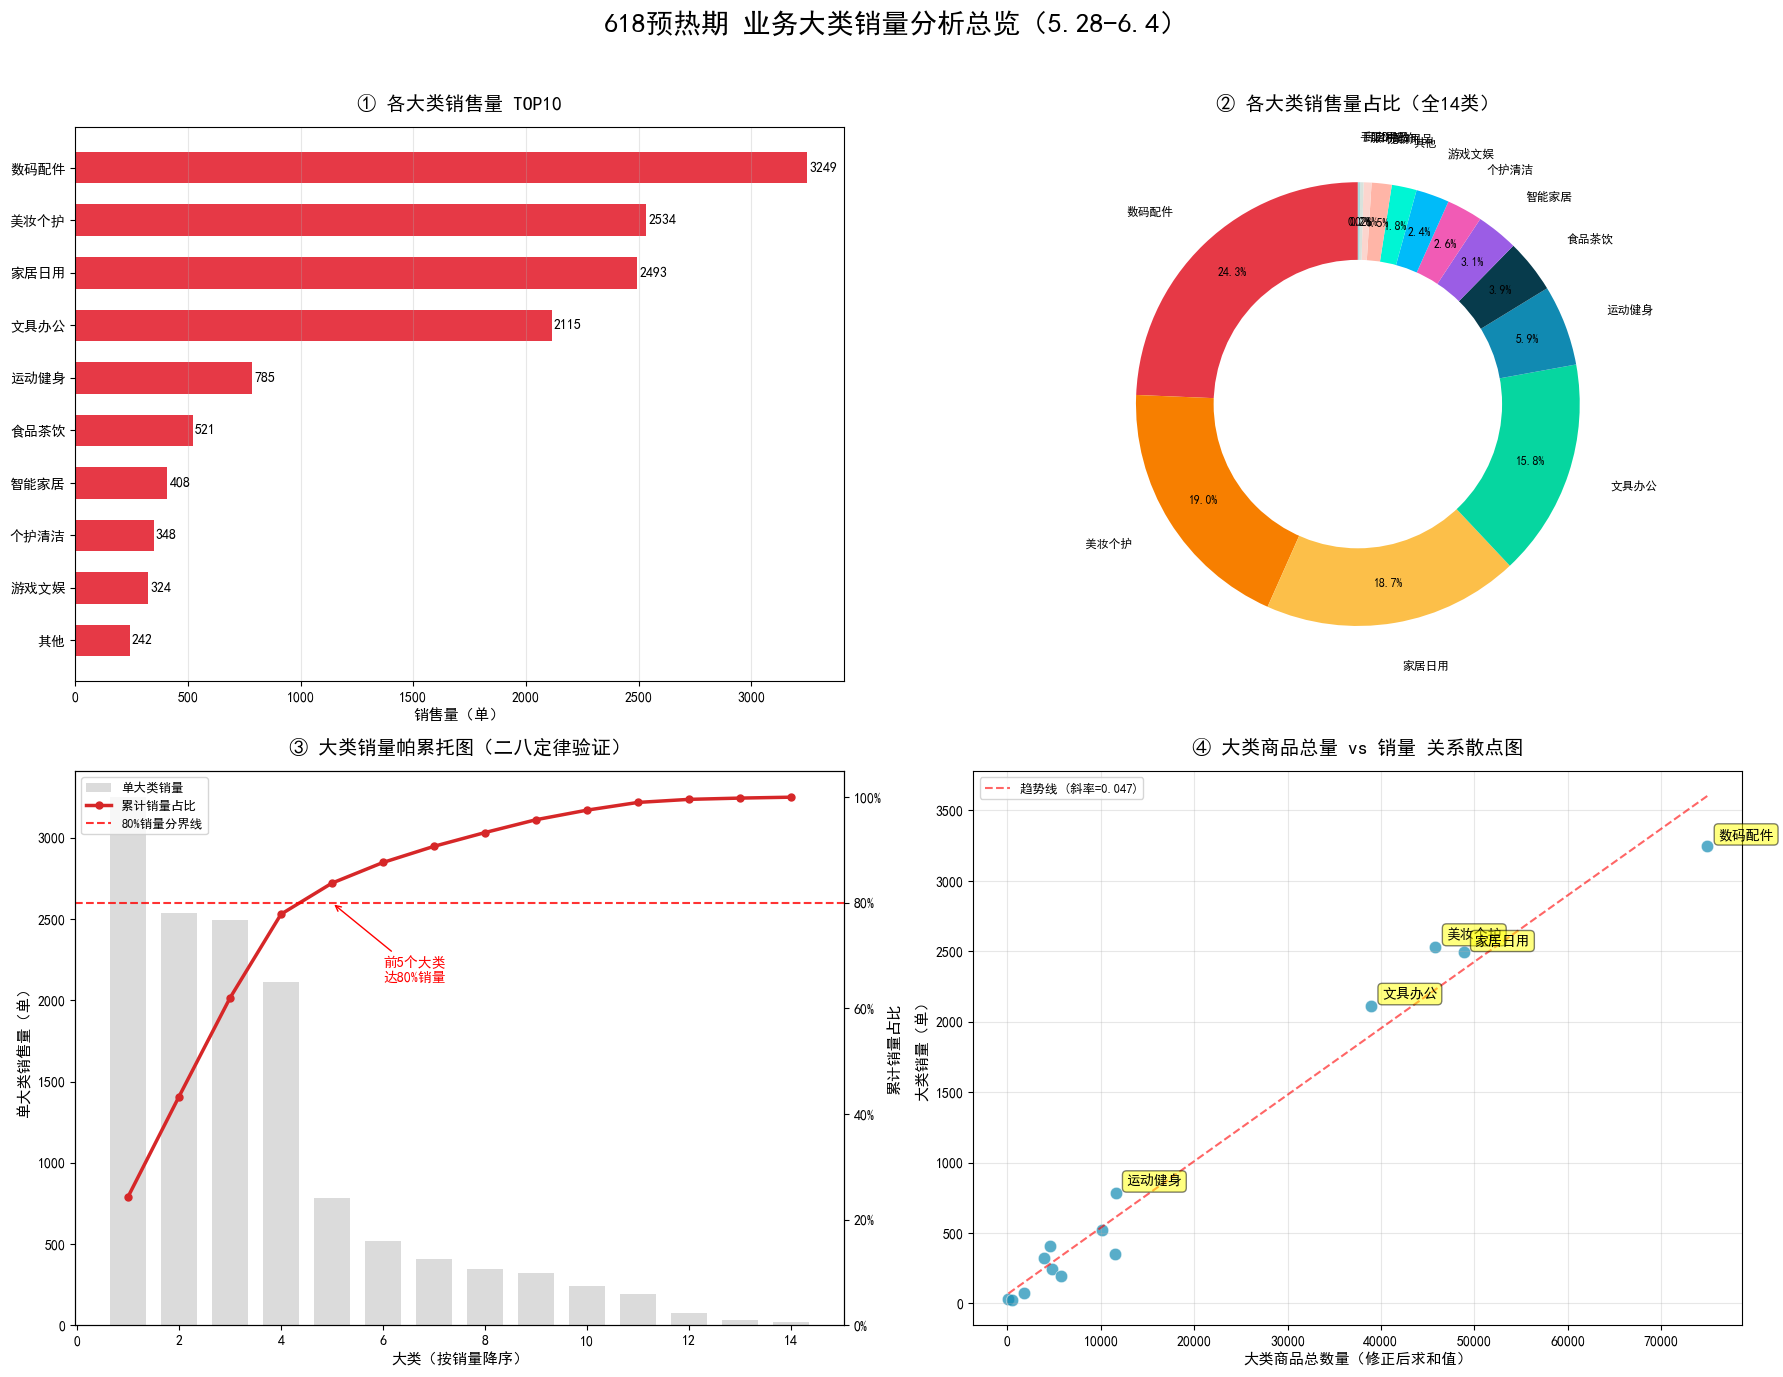


🖼️  单独保存各张图
✅ 图1已保存：业务品类TOP10.png
✅ 图2已保存：业务品类占比饼图.png
✅ 图3已保存：业务品类帕累托图.png
✅ 图4已保存：商品规模vs销量散点.png

📋 关键分析结论

总购买订单：13,346
大类总数：14
TOP1大类：数码配件，销量 3249 单，占比 24.34%
TOP3大类总销量占比：62.01%
TOP5大类总销量占比：83.74%
覆盖80%销量需要前 5 个大类，占全部大类的 35.71%

⚠️  不完全符合二八定律：需要35.7%的大类才覆盖80%销量，长尾更明显
商品总量与销量相关系数：0.987
  → 强正相关：商品越多销量越高

🎉 全部文件输出完成清单

📦 CSV文件：
  1. 业务品类销量明细.csv （销量、占比、修正后大类商品总量）

🖼️ 图片文件：
  1. 业务大类分析总览_四图合一.png （2*2子图总览）
  2. 业务品类TOP10.png
  3. 业务品类占比饼图.png （全14大类+虚线引线）
  4. 业务品类帕累托图.png
  5. 商品规模vs销量散点.png （商品总量已修正）



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据_带大类.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")
print(f"大类数量：{df['大类'].nunique()}")

# ============================================================
# 第一部分：按大类聚合销量 + 修正大类商品总量计算
# ============================================================
print("\n" + "="*60)
print("📊 按大类聚合销量")
print("="*60)

# 只筛选购买行为
df_buy = df[df["behavior"] == "buy"].reset_index(drop=True)
total_buy = len(df_buy)
print(f"总购买订单数：{total_buy:,}")

# 1. 先统计各大类销量（正确：统计buy记录条数）
cat_sales = df_buy.groupby("大类").agg(销量=("user_id", "count")).reset_index()
cat_sales = cat_sales.sort_values("销量", ascending=False).reset_index(drop=True)

# 2. 【修复】计算每个大类真实总商品数：去重所有细分品类后求和
# 同一细品类只保留1条，避免重复累加商品数量
unique_category = df.drop_duplicates(subset=["大类", "category_label"])[["大类", "category_label", "品类商品数"]]
goods_sum = unique_category.groupby("大类")["品类商品数"].sum().reset_index()
goods_sum.rename(columns={"品类商品数": "品类商品数"}, inplace=True)

# 合并销量、大类商品总量
cat_sales = pd.merge(cat_sales, goods_sum, on="大类", how="left")

# 计算占比、累计指标
cat_sales["销量占比%"] = round(cat_sales["销量"] / total_buy * 100, 2)
cat_sales["累计销量"] = cat_sales["销量"].cumsum()
cat_sales["累计占比"] = cat_sales["累计销量"] / total_buy

print(f"\n==== 各大类销量明细 ====")
print(cat_sales[["大类", "销量", "销量占比%", "累计占比", "品类商品数"]].to_string(index=False))

# 保存销量明细csv
sales_csv = f"{base_path}\\业务品类销量明细.csv"
cat_sales.to_csv(sales_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ 销量明细已保存：业务品类销量明细.csv")

# ============================================================
# 第二部分：4张子图组合大图（2行2列）
# ============================================================
print("\n" + "="*60)
print("🎨 生成子图组合大图")
print("="*60)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('618预热期 业务大类销量分析总览（5.28-6.4）', fontsize=20, fontweight='bold', y=0.98)

# ---------- 子图1：大类销量TOP10 横向柱状图 ----------
ax1 = plt.subplot(2, 2, 1)
top10 = cat_sales.head(10)
bars = ax1.barh(top10["大类"][::-1], top10["销量"][::-1], color='#E63946', height=0.6)
ax1.set_title('① 各大类销售量 TOP10', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('销售量（单）', fontsize=11)
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}', ha='left', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# ---------- 子图2：大类销量占比饼图（全14类+虚线引线防遮挡）----------
ax2 = plt.subplot(2, 2, 2)
pie_data = cat_sales[["大类", "销量"]].copy()

# 14类专属配色
colors = [
    '#E63946', '#F77F00', '#FCBF49', '#06D6A0', '#118AB2',
    '#073B4C', '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4',
    '#FFB5A7', '#FCD5CE', '#D8E2DC', '#A8DADC'
]

wedges, texts, autotexts = ax2.pie(
    pie_data["销量"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    labeldistance=1.2,    # 向外引出虚线，解决标签重叠遮挡
    textprops={'fontsize': 8.5}
)
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('② 各大类销售量占比（全14类）', fontsize=14, fontweight='bold', pad=12)

# ---------- 子图3：帕累托二八验证图 ----------
ax3 = plt.subplot(2, 2, 3)
ax3_twin = ax3.twinx()

cat_sales_sorted = cat_sales.reset_index(drop=True)
cat_sales_sorted["大类序号"] = range(1, len(cat_sales_sorted)+1)

ax3.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销量"],
        color='#cccccc', alpha=0.7, label='单大类销量', width=0.7)
ax3_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"],
              color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销量占比')
ax3_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')

ax3.set_xlabel('大类（按销量降序）', fontsize=11)
ax3.set_ylabel('单大类销售量（单）', fontsize=11)
ax3_twin.set_ylabel('累计销量占比', fontsize=11)
ax3_twin.set_ylim(0, 1.05)
ax3_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3.set_title('③ 大类销量帕累托图（二八定律验证）', fontsize=14, fontweight='bold', pad=12)

# 标注80%销量对应大类序号
eight_pct_idx = cat_sales_sorted[cat_sales_sorted["累计占比"] >= 0.8].iloc[0]["大类序号"]
ax3_twin.annotate(f'前{int(eight_pct_idx)}个大类\n达80%销量',
                  xy=(eight_pct_idx, 0.8),
                  xytext=(eight_pct_idx+1, 0.65),
                  fontsize=10, color='red',
                  arrowprops=dict(arrowstyle='->', color='red'))

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ---------- 子图4：商品总量vs销量散点图（数据已修复） ----------
ax4 = plt.subplot(2, 2, 4)
scatter_data = cat_sales[(cat_sales["品类商品数"] > 0) & (cat_sales["销量"] > 0)]

scatter = ax4.scatter(scatter_data["品类商品数"], scatter_data["销量"],
                      alpha=0.7, s=80, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4.set_xlabel('大类商品总数量（修正后求和值）', fontsize=11)
ax4.set_ylabel('大类销量（单）', fontsize=11)
ax4.set_title('④ 大类商品总量 vs 销量 关系散点图', fontsize=14, fontweight='bold', pad=12)
ax4.grid(True, alpha=0.3)

# 标注TOP5销量大类
top5 = scatter_data.sort_values("销量", ascending=False).head(5)
for _, row in top5.iterrows():
    ax4.annotate(row["大类"],
                 (row["品类商品数"], row["销量"]),
                 xytext=(8, 5), textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 线性趋势线
z = np.polyfit(scatter_data["品类商品数"], scatter_data["销量"], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4.plot(x_line, p(x_line), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z[0]:.3f})')
ax4.legend(fontsize=9)

# 布局自适应
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 保存四合一总图表
combined_png = f"{base_path}\\业务大类分析总览_四图合一.png"
plt.savefig(combined_png, dpi=200, bbox_inches='tight')
print(f"✅ 组合大图已保存：业务大类分析总览_四图合一.png")
plt.show()

# ============================================================
# 第三部分：独立导出四张单图
# ============================================================
print("\n" + "="*60)
print("🖼️  单独保存各张图")
print("="*60)

# 1、TOP10柱状图
fig1, ax1_single = plt.subplots(figsize=(12, 6))
bars1 = ax1_single.barh(top10["大类"][::-1], top10["销量"][::-1], color='#E63946', height=0.6)
ax1_single.set_title('业务大类销售量 TOP10（618预热期 5.28-6.4）', fontsize=16, fontweight='bold')
ax1_single.set_xlabel('销售量（单）', fontsize=12)
for bar in bars1:
    width = bar.get_width()
    ax1_single.text(width + 10, bar.get_y() + bar.get_height()/2.,
                    f'{int(width)}', ha='left', va='center', fontsize=11)
ax1_single.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类TOP10.png", dpi=150, bbox_inches='tight')
print("✅ 图1已保存：业务品类TOP10.png")
plt.close()

# 2、全14类饼图（带引线）
fig2, ax2_single = plt.subplots(figsize=(12, 12))
wedges2, texts2, autotexts2 = ax2_single.pie(
    pie_data["销量"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    labeldistance=1.22,
    textprops={'fontsize': 11}
)
centre_circle2 = plt.Circle((0, 0), 0.70, fc='white')
ax2_single.add_artist(centre_circle2)
ax2_single.set_title('各大类销售量占比（全14类）', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类占比饼图.png", dpi=150, bbox_inches='tight')
print("✅ 图2已保存：业务品类占比饼图.png")
plt.close()

# 3、帕累托图 【✅ 已修复：补上100%标签】
fig3, ax3_single = plt.subplots(figsize=(14, 7))
ax3_single_twin = ax3_single.twinx()
ax3_single.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销量"],
               color='#cccccc', alpha=0.7, label='单大类销量', width=0.7)
ax3_single_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"],
                     color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销量占比')
ax3_single_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')
ax3_single.set_xlabel('大类（按销量降序排列）', fontsize=12)
ax3_single.set_ylabel('单大类销售量（单）', fontsize=12)
ax3_single_twin.set_ylabel('累计销量占比', fontsize=12)
ax3_single_twin.set_ylim(0, 1.05)
ax3_single_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
# ✅ 修复：补上 '100%'，6个刻度对应6个标签
ax3_single_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3_single.set_title('业务大类销量帕累托图（长尾分布分析）', fontsize=16, fontweight='bold')
lines3, labels3 = ax3_single.get_legend_handles_labels()
lines4, labels4 = ax3_single_twin.get_legend_handles_labels()
ax3_single.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类帕累托图.png", dpi=150, bbox_inches='tight')
print("✅ 图3已保存：业务品类帕累托图.png")
plt.close()

# 4、商品销量散点图（修复后数据）
fig4, ax4_single = plt.subplots(figsize=(12, 7))
scatter4 = ax4_single.scatter(scatter_data["品类商品数"], scatter_data["销量"],
                              alpha=0.7, s=100, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4_single.set_xlabel('大类商品总数量', fontsize=12)
ax4_single.set_ylabel('大类销量（单）', fontsize=12)
ax4_single.set_title('大类商品总量 vs 销量 关系散点图', fontsize=16, fontweight='bold')
ax4_single.grid(True, alpha=0.3)
top5_4 = scatter_data.sort_values("销量", ascending=False).head(5)
for _, row in top5_4.iterrows():
    ax4_single.annotate(row["大类"],
                        (row["品类商品数"], row["销量"]),
                        xytext=(8, 5), textcoords='offset points', fontsize=11,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
z4 = np.polyfit(scatter_data["品类商品数"], scatter_data["销量"], 1)
p4 = np.poly1d(z4)
x_line4 = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4_single.plot(x_line4, p4(x_line4), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z4[0]:.3f})')
ax4_single.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\商品规模vs销量散点.png", dpi=150, bbox_inches='tight')
print("✅ 图4已保存：商品规模vs销量散点.png")
plt.close()

# ============================================================
# 第四部分：控制台输出关键指标
# ============================================================
print("\n" + "="*60)
print("📋 关键分析结论")
print("="*60)

print(f"\n总购买订单：{total_buy:,}")
print(f"大类总数：{len(cat_sales)}")
print(f"TOP1大类：{cat_sales.iloc[0]['大类']}，销量 {cat_sales.iloc[0]['销量']} 单，占比 {cat_sales.iloc[0]['销量占比%']}%")
print(f"TOP3大类总销量占比：{cat_sales.head(3)['销量占比%'].sum():.2f}%")
print(f"TOP5大类总销量占比：{cat_sales.head(5)['销量占比%'].sum():.2f}%")
print(f"覆盖80%销量需要前 {int(eight_pct_idx)} 个大类，占全部大类的 {eight_pct_idx/len(cat_sales)*100:.2f}%")

# 二八判定
if eight_pct_idx / len(cat_sales) <= 0.25:
    print(f"\n✅ 基本符合二八定律：前{eight_pct_idx/len(cat_sales)*100:.1f}%的大类贡献80%销量")
else:
    print(f"\n⚠️  不完全符合二八定律：需要{eight_pct_idx/len(cat_sales)*100:.1f}%的大类才覆盖80%销量，长尾更明显")

# 商品数量&销量相关性（数据已修复，结果可信）
corr = scatter_data["品类商品数"].corr(scatter_data["销量"])
print(f"商品总量与销量相关系数：{corr:.3f}")
if corr > 0.7:
    print("  → 强正相关：商品越多销量越高")
elif corr > 0.4:
    print("  → 中等正相关：商品数对销量有一定影响")
else:
    print("  → 弱相关：商品总量不是销量决定性因素")

print("\n" + "="*60)
print("🎉 全部文件输出完成清单")
print("="*60)
print("""
📦 CSV文件：
  1. 业务品类销量明细.csv （销量、占比、修正后大类商品总量）

🖼️ 图片文件：
  1. 业务大类分析总览_四图合一.png （2*2子图总览）
  2. 业务品类TOP10.png
  3. 业务品类占比饼图.png （全14大类+虚线引线）
  4. 业务品类帕累托图.png
  5. 商品规模vs销量散点.png （商品总量已修正）
""")

📥 读取成功，总行数：755,536
大类数量：14

📊 按大类聚合销售件数
总购买订单数：13,346
总销售件数：33,311 件

==== 各大类销售件数明细 ====
   大类  销售件数  销量占比%     累计占比  品类商品数
 数码配件  8136  24.42 0.244244  74973
 美妆个护  6315  18.96 0.433821  45848
 家居日用  6198  18.61 0.619885  48863
 文具办公  5262  15.80 0.777851  38947
 运动健身  1957   5.87 0.836601  11573
 食品茶饮  1277   3.83 0.874936  10097
 智能家居  1051   3.16 0.906487   4535
 个护清洁   863   2.59 0.932395  11553
 游戏文娱   824   2.47 0.957131   3955
   其他   616   1.85 0.975624   4809
 宠物用品   490   1.47 0.990334   5688
 服饰配饰   179   0.54 0.995707   1802
 厨房用品    77   0.23 0.998019    101
手工DIY    66   0.20 1.000000    479

✅ 销量明细已保存：业务品类销量明细.csv

🎨 生成子图组合大图
✅ 组合大图已保存：业务大类分析总览_四图合一.png


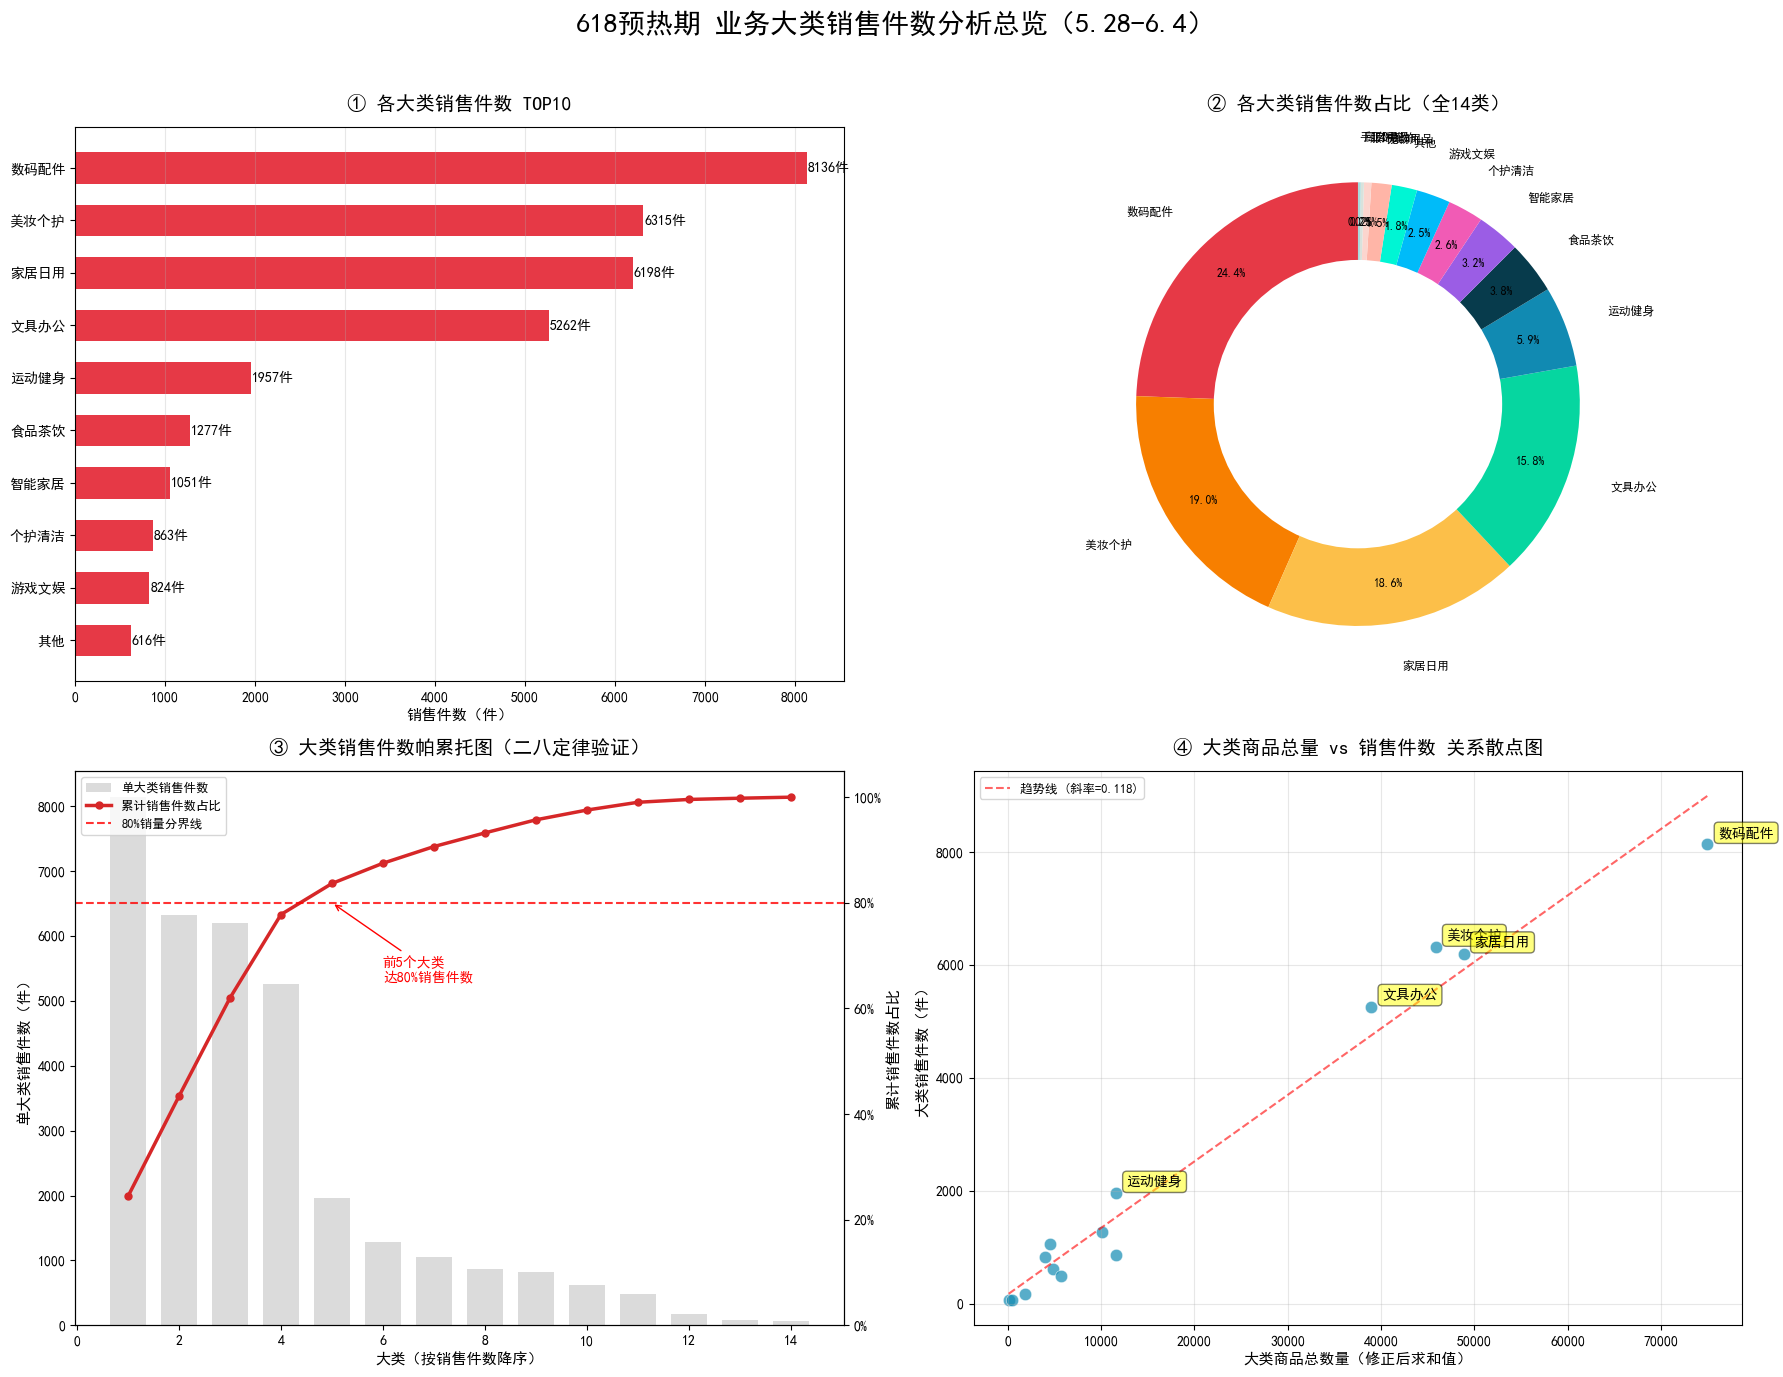


🖼️  单独保存各张图
✅ 图1已保存：业务品类TOP10.png
✅ 图2已保存：业务品类占比饼图.png
✅ 图3已保存：业务品类帕累托图.png
✅ 图4已保存：商品规模vs销量散点.png

📋 关键分析结论

总销售件数：33,311 件
总购买订单数：13,346 单
大类总数：14
TOP1大类：数码配件，销售件数 8136 件，占比 24.42%
TOP3大类总销售件数占比：61.99%
TOP5大类总销售件数占比：83.66%
覆盖80%销售件数需要前 5 个大类，占全部大类的 35.71%

⚠️  不完全符合二八定律：需要35.7%的大类才覆盖80%销售件数，长尾更明显
商品总量与销售件数相关系数：0.987
  → 强正相关：商品越多销售件数越高

🎉 全部文件输出完成清单

📦 CSV文件：
  1. 业务品类销量明细.csv （销售件数、占比、修正后大类商品总量）

🖼️ 图片文件：
  1. 业务大类分析总览_四图合一.png （2*2子图总览）
  2. 业务品类TOP10.png
  3. 业务品类占比饼图.png （全14大类+虚线引线）
  4. 业务品类帕累托图.png
  5. 商品规模vs销量散点.png （商品总量已修正）



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据_带大类.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")
print(f"大类数量：{df['大类'].nunique()}")

# ============================================================
# 第一部分：按大类聚合销售件数 + 修正大类商品总量计算
# ============================================================
print("\n" + "="*60)
print("📊 按大类聚合销售件数")
print("="*60)

# 只筛选购买行为
df_buy = df[df["behavior"] == "buy"].reset_index(drop=True)
total_buy = len(df_buy)
total_amount = df_buy["amount"].sum()    # 总销售件数
print(f"总购买订单数：{total_buy:,}")
print(f"总销售件数：{total_amount:,} 件")

# 1. 统计各大类销售件数（sum(amount)）
cat_sales = df_buy.groupby("大类").agg(销售件数=("amount", "sum")).reset_index()
cat_sales = cat_sales.sort_values("销售件数", ascending=False).reset_index(drop=True)

# 2. 计算每个大类真实总商品数：去重所有细分品类后求和
unique_category = df.drop_duplicates(subset=["大类", "category_label"])[["大类", "category_label", "品类商品数"]]
goods_sum = unique_category.groupby("大类")["品类商品数"].sum().reset_index()
goods_sum.rename(columns={"品类商品数": "品类商品数"}, inplace=True)

# 合并销售件数、大类商品总量
cat_sales = pd.merge(cat_sales, goods_sum, on="大类", how="left")

# 计算占比、累计指标（分母改为总销售件数）
cat_sales["销量占比%"] = round(cat_sales["销售件数"] / total_amount * 100, 2)
cat_sales["累计销量"] = cat_sales["销售件数"].cumsum()
cat_sales["累计占比"] = cat_sales["累计销量"] / total_amount

print(f"\n==== 各大类销售件数明细 ====")
print(cat_sales[["大类", "销售件数", "销量占比%", "累计占比", "品类商品数"]].to_string(index=False))

# 保存销量明细csv
sales_csv = f"{base_path}\\业务品类销量明细.csv"
cat_sales.to_csv(sales_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ 销量明细已保存：业务品类销量明细.csv")

# ============================================================
# 第二部分：4张子图组合大图（2行2列）
# ============================================================
print("\n" + "="*60)
print("🎨 生成子图组合大图")
print("="*60)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('618预热期 业务大类销售件数分析总览（5.28-6.4）', fontsize=20, fontweight='bold', y=0.98)

# ---------- 子图1：大类销售件数TOP10 横向柱状图 ----------
ax1 = plt.subplot(2, 2, 1)
top10 = cat_sales.head(10)
bars = ax1.barh(top10["大类"][::-1], top10["销售件数"][::-1], color='#E63946', height=0.6)
ax1.set_title('① 各大类销售件数 TOP10', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('销售件数（件）', fontsize=11)
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}件', ha='left', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# ---------- 子图2：大类销售件数占比饼图（全14类+虚线引线防遮挡）----------
ax2 = plt.subplot(2, 2, 2)
pie_data = cat_sales[["大类", "销售件数"]].copy()

# 14类专属配色
colors = [
    '#E63946', '#F77F00', '#FCBF49', '#06D6A0', '#118AB2',
    '#073B4C', '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4',
    '#FFB5A7', '#FCD5CE', '#D8E2DC', '#A8DADC'
]

wedges, texts, autotexts = ax2.pie(
    pie_data["销售件数"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    labeldistance=1.2,    # 向外引出虚线，解决标签重叠遮挡
    textprops={'fontsize': 8.5}
)
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('② 各大类销售件数占比（全14类）', fontsize=14, fontweight='bold', pad=12)

# ---------- 子图3：帕累托二八验证图 ----------
ax3 = plt.subplot(2, 2, 3)
ax3_twin = ax3.twinx()

cat_sales_sorted = cat_sales.reset_index(drop=True)
cat_sales_sorted["大类序号"] = range(1, len(cat_sales_sorted)+1)

ax3.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销售件数"],
        color='#cccccc', alpha=0.7, label='单大类销售件数', width=0.7)
ax3_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"],
              color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销售件数占比')
ax3_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')

ax3.set_xlabel('大类（按销售件数降序）', fontsize=11)
ax3.set_ylabel('单大类销售件数（件）', fontsize=11)
ax3_twin.set_ylabel('累计销售件数占比', fontsize=11)
ax3_twin.set_ylim(0, 1.05)
ax3_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3.set_title('③ 大类销售件数帕累托图（二八定律验证）', fontsize=14, fontweight='bold', pad=12)

# 标注80%销量对应大类序号
eight_pct_idx = cat_sales_sorted[cat_sales_sorted["累计占比"] >= 0.8].iloc[0]["大类序号"]
ax3_twin.annotate(f'前{int(eight_pct_idx)}个大类\n达80%销售件数',
                  xy=(eight_pct_idx, 0.8),
                  xytext=(eight_pct_idx+1, 0.65),
                  fontsize=10, color='red',
                  arrowprops=dict(arrowstyle='->', color='red'))

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ---------- 子图4：商品总量vs销售件数散点图 ----------
ax4 = plt.subplot(2, 2, 4)
scatter_data = cat_sales[(cat_sales["品类商品数"] > 0) & (cat_sales["销售件数"] > 0)]

scatter = ax4.scatter(scatter_data["品类商品数"], scatter_data["销售件数"],
                      alpha=0.7, s=80, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4.set_xlabel('大类商品总数量（修正后求和值）', fontsize=11)
ax4.set_ylabel('大类销售件数（件）', fontsize=11)
ax4.set_title('④ 大类商品总量 vs 销售件数 关系散点图', fontsize=14, fontweight='bold', pad=12)
ax4.grid(True, alpha=0.3)

# 标注TOP5销售件数大类
top5 = scatter_data.sort_values("销售件数", ascending=False).head(5)
for _, row in top5.iterrows():
    ax4.annotate(row["大类"],
                 (row["品类商品数"], row["销售件数"]),
                 xytext=(8, 5), textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 线性趋势线
z = np.polyfit(scatter_data["品类商品数"], scatter_data["销售件数"], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4.plot(x_line, p(x_line), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z[0]:.3f})')
ax4.legend(fontsize=9)

# 布局自适应
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 保存四合一总图表
combined_png = f"{base_path}\\业务大类分析总览_四图合一.png"
plt.savefig(combined_png, dpi=200, bbox_inches='tight')
print(f"✅ 组合大图已保存：业务大类分析总览_四图合一.png")
plt.show()

# ============================================================
# 第三部分：独立导出四张单图
# ============================================================
print("\n" + "="*60)
print("🖼️  单独保存各张图")
print("="*60)

# 1、TOP10柱状图
fig1, ax1_single = plt.subplots(figsize=(12, 6))
bars1 = ax1_single.barh(top10["大类"][::-1], top10["销售件数"][::-1], color='#E63946', height=0.6)
ax1_single.set_title('业务大类销售件数 TOP10（618预热期 5.28-6.4）', fontsize=16, fontweight='bold')
ax1_single.set_xlabel('销售件数（件）', fontsize=12)
for bar in bars1:
    width = bar.get_width()
    ax1_single.text(width + 10, bar.get_y() + bar.get_height()/2.,
                    f'{int(width)}件', ha='left', va='center', fontsize=11)
ax1_single.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类TOP10.png", dpi=150, bbox_inches='tight')
print("✅ 图1已保存：业务品类TOP10.png")
plt.close()

# 2、全14类饼图（带引线）
fig2, ax2_single = plt.subplots(figsize=(12, 12))
wedges2, texts2, autotexts2 = ax2_single.pie(
    pie_data["销售件数"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    labeldistance=1.22,
    textprops={'fontsize': 11}
)
centre_circle2 = plt.Circle((0, 0), 0.70, fc='white')
ax2_single.add_artist(centre_circle2)
ax2_single.set_title('各大类销售件数占比（全14类）', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类占比饼图.png", dpi=150, bbox_inches='tight')
print("✅ 图2已保存：业务品类占比饼图.png")
plt.close()

# 3、帕累托图
fig3, ax3_single = plt.subplots(figsize=(14, 7))
ax3_single_twin = ax3_single.twinx()
ax3_single.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销售件数"],
               color='#cccccc', alpha=0.7, label='单大类销售件数', width=0.7)
ax3_single_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"],
                     color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销售件数占比')
ax3_single_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')
ax3_single.set_xlabel('大类（按销售件数降序排列）', fontsize=12)
ax3_single.set_ylabel('单大类销售件数（件）', fontsize=12)
ax3_single_twin.set_ylabel('累计销售件数占比', fontsize=12)
ax3_single_twin.set_ylim(0, 1.05)
ax3_single_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_single_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3_single.set_title('业务大类销售件数帕累托图（长尾分布分析）', fontsize=16, fontweight='bold')
lines3, labels3 = ax3_single.get_legend_handles_labels()
lines4, labels4 = ax3_single_twin.get_legend_handles_labels()
ax3_single.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类帕累托图.png", dpi=150, bbox_inches='tight')
print("✅ 图3已保存：业务品类帕累托图.png")
plt.close()

# 4、商品销量散点图
fig4, ax4_single = plt.subplots(figsize=(12, 7))
scatter4 = ax4_single.scatter(scatter_data["品类商品数"], scatter_data["销售件数"],
                              alpha=0.7, s=100, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4_single.set_xlabel('大类商品总数量', fontsize=12)
ax4_single.set_ylabel('大类销售件数（件）', fontsize=12)
ax4_single.set_title('大类商品总量 vs 销售件数 关系散点图', fontsize=16, fontweight='bold')
ax4_single.grid(True, alpha=0.3)
top5_4 = scatter_data.sort_values("销售件数", ascending=False).head(5)
for _, row in top5_4.iterrows():
    ax4_single.annotate(row["大类"],
                        (row["品类商品数"], row["销售件数"]),
                        xytext=(8, 5), textcoords='offset points', fontsize=11,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
z4 = np.polyfit(scatter_data["品类商品数"], scatter_data["销售件数"], 1)
p4 = np.poly1d(z4)
x_line4 = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4_single.plot(x_line4, p4(x_line4), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z4[0]:.3f})')
ax4_single.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\商品规模vs销量散点.png", dpi=150, bbox_inches='tight')
print("✅ 图4已保存：商品规模vs销量散点.png")
plt.close()

# ============================================================
# 第四部分：控制台输出关键指标
# ============================================================
print("\n" + "="*60)
print("📋 关键分析结论")
print("="*60)

print(f"\n总销售件数：{total_amount:,} 件")
print(f"总购买订单数：{total_buy:,} 单")
print(f"大类总数：{len(cat_sales)}")
print(f"TOP1大类：{cat_sales.iloc[0]['大类']}，销售件数 {cat_sales.iloc[0]['销售件数']} 件，占比 {cat_sales.iloc[0]['销量占比%']}%")
print(f"TOP3大类总销售件数占比：{cat_sales.head(3)['销量占比%'].sum():.2f}%")
print(f"TOP5大类总销售件数占比：{cat_sales.head(5)['销量占比%'].sum():.2f}%")
print(f"覆盖80%销售件数需要前 {int(eight_pct_idx)} 个大类，占全部大类的 {eight_pct_idx/len(cat_sales)*100:.2f}%")

# 二八判定
if eight_pct_idx / len(cat_sales) <= 0.25:
    print(f"\n✅ 基本符合二八定律：前{eight_pct_idx/len(cat_sales)*100:.1f}%的大类贡献80%销售件数")
else:
    print(f"\n⚠️  不完全符合二八定律：需要{eight_pct_idx/len(cat_sales)*100:.1f}%的大类才覆盖80%销售件数，长尾更明显")

# 商品数量&销量相关性
corr = scatter_data["品类商品数"].corr(scatter_data["销售件数"])
print(f"商品总量与销售件数相关系数：{corr:.3f}")
if corr > 0.7:
    print("  → 强正相关：商品越多销售件数越高")
elif corr > 0.4:
    print("  → 中等正相关：商品数对销售件数有一定影响")
else:
    print("  → 弱相关：商品总量不是销售件数决定性因素")

print("\n" + "="*60)
print("🎉 全部文件输出完成清单")
print("="*60)
print("""
📦 CSV文件：
  1. 业务品类销量明细.csv （销售件数、占比、修正后大类商品总量）

🖼️ 图片文件：
  1. 业务大类分析总览_四图合一.png （2*2子图总览）
  2. 业务品类TOP10.png
  3. 业务品类占比饼图.png （全14大类+虚线引线）
  4. 业务品类帕累托图.png
  5. 商品规模vs销量散点.png （商品总量已修正）
""")

📥 读取成功，总行数：755,536
大类数量：14

📊 按大类聚合销售件数
总购买订单数：13,346
总销售件数：33,311 件

==== 各大类销售件数明细 ====
   大类  销售件数  销量占比%     累计占比  品类商品数
 数码配件  8136  24.42 0.244244  74973
 美妆个护  6315  18.96 0.433821  45848
 家居日用  6198  18.61 0.619885  48863
 文具办公  5262  15.80 0.777851  38947
 运动健身  1957   5.87 0.836601  11573
 食品茶饮  1277   3.83 0.874936  10097
 智能家居  1051   3.16 0.906487   4535
 个护清洁   863   2.59 0.932395  11553
 游戏文娱   824   2.47 0.957131   3955
   其他   616   1.85 0.975624   4809
 宠物用品   490   1.47 0.990334   5688
 服饰配饰   179   0.54 0.995707   1802
 厨房用品    77   0.23 0.998019    101
手工DIY    66   0.20 1.000000    479

✅ 销量明细已保存：业务品类销量明细.csv

🎨 生成子图组合大图
✅ 组合大图已保存：业务大类分析总览_四图合一.png


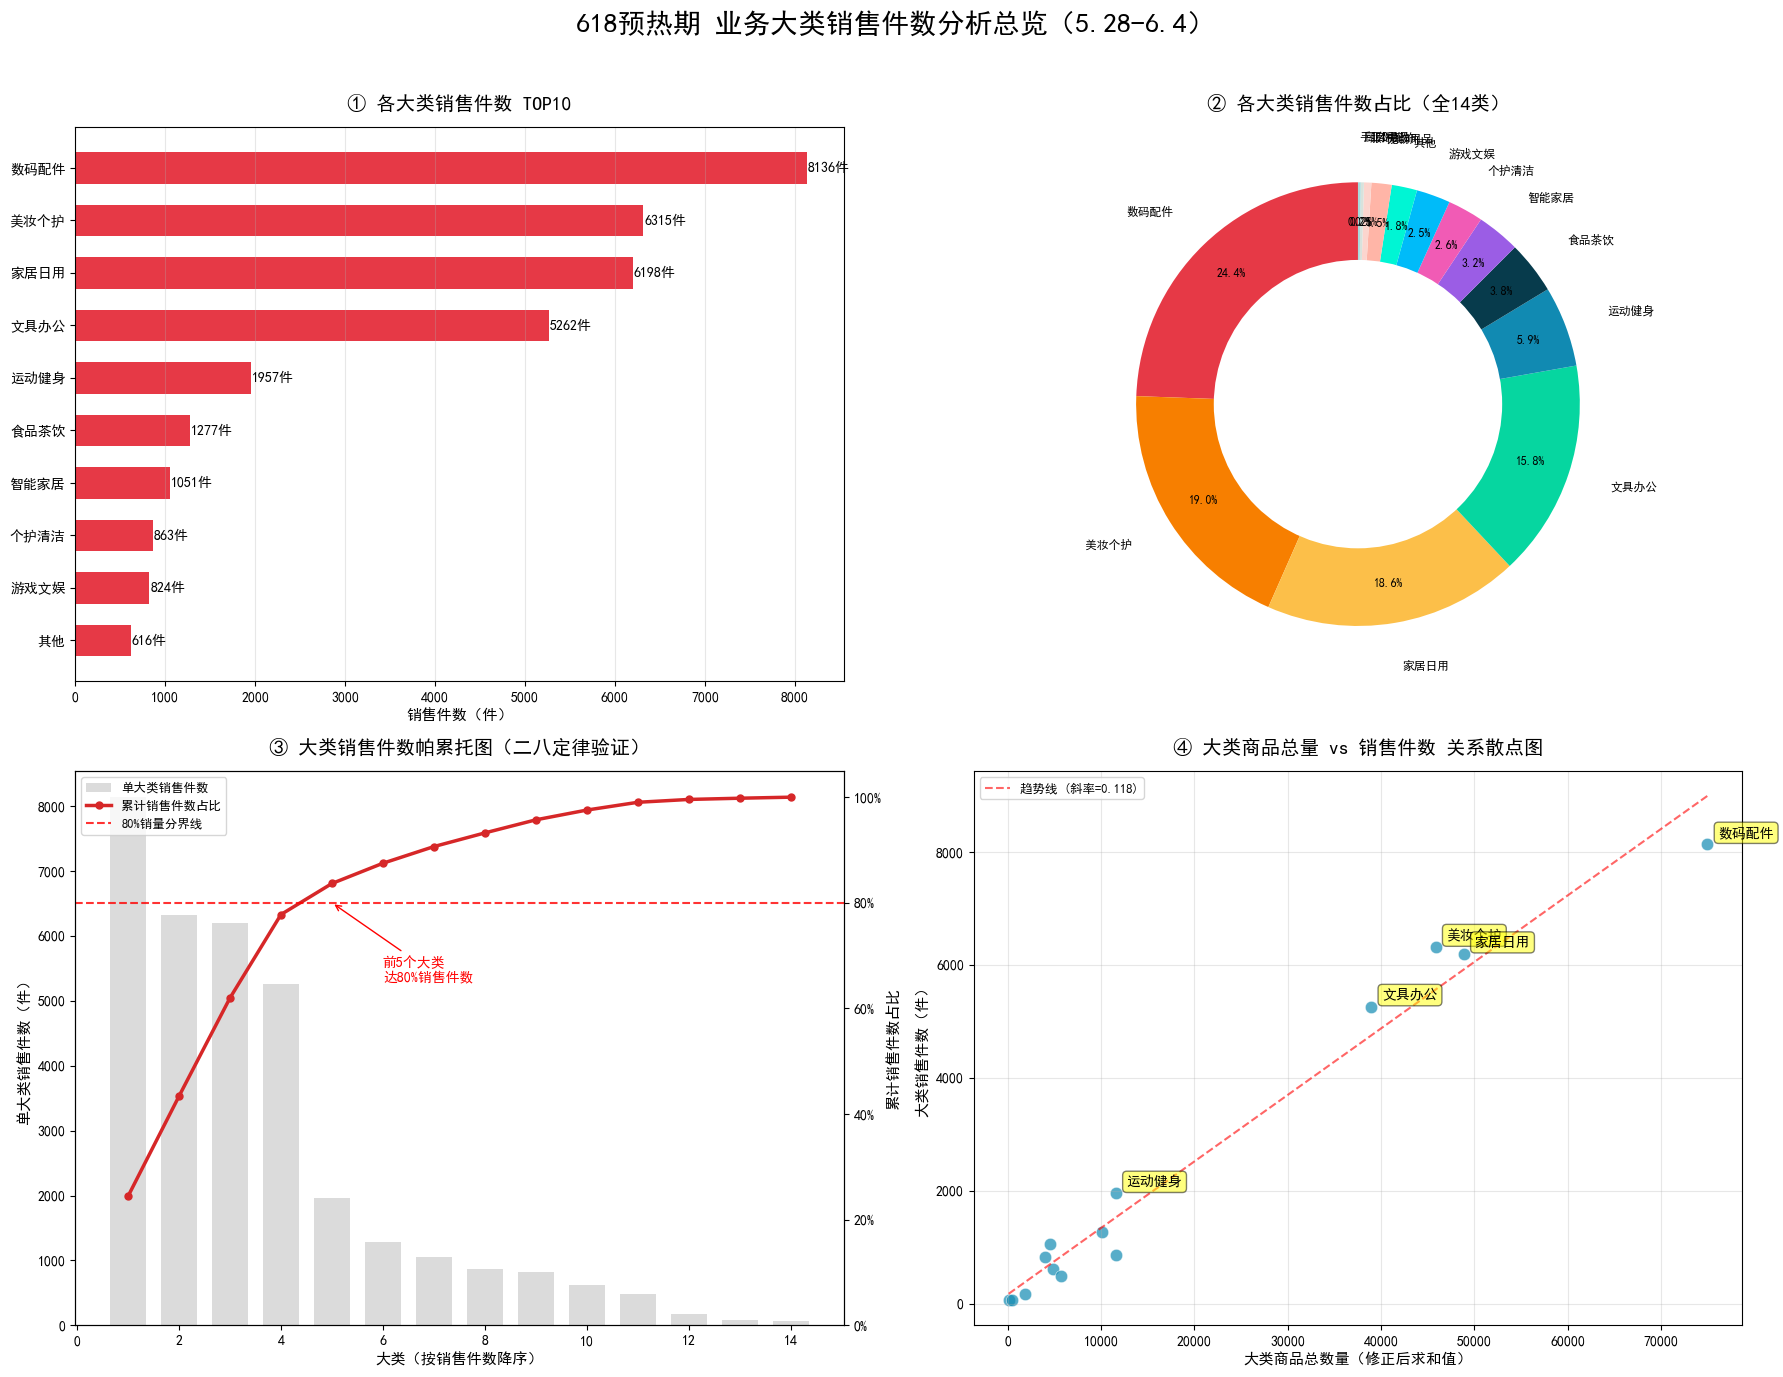


🖼️  单独保存各张图
✅ 图1已保存：业务品类TOP10.png
✅ 图2已保存：业务品类占比饼图.png
✅ 图3已保存：业务品类帕累托图.png
✅ 图4已保存：商品规模vs销量散点.png

📋 关键分析结论

总销售件数：33,311 件
总购买订单数：13,346 单
大类总数：14
TOP1大类：数码配件，销售件数 8136 件，占比 24.42%
TOP3大类总销售件数占比：61.99%
TOP5大类总销售件数占比：83.66%
覆盖80%销售件数需要前 5 个大类，占全部大类的 35.71%

⚠️  不完全符合二八定律：需要35.7%的大类才覆盖80%销售件数，长尾更明显
商品总量与销售件数相关系数：0.987
  → 强正相关：商品越多销售件数越高

🎉 全部文件输出完成清单

📦 CSV文件：
  1. 业务品类销量明细.csv （销售件数、占比、修正后大类商品总量）

🖼️ 图片文件：
  1. 业务大类分析总览_四图合一.png （2*2子图总览）
  2. 业务品类TOP10.png
  3. 业务品类占比饼图.png （全14大类+虚线引线）
  4. 业务品类帕累托图.png
  5. 商品规模vs销量散点.png （商品总量已修正）



In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据_带大类.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")
print(f"大类数量：{df['大类'].nunique()}")

# ============================================================
# 第一部分：按大类聚合销售件数 + 修正大类商品总量计算
# ============================================================
print("\n" + "="*60)
print("📊 按大类聚合销售件数")
print("="*60)

# 只筛选购买行为
df_buy = df[df["behavior"] == "buy"].reset_index(drop=True)
total_buy = len(df_buy)
total_amount = df_buy["amount"].sum()    # 总销售件数
print(f"总购买订单数：{total_buy:,}")
print(f"总销售件数：{total_amount:,} 件")

# 1. 统计各大类销售件数（sum(amount)）
cat_sales = df_buy.groupby("大类").agg(销售件数=("amount", "sum")).reset_index()
cat_sales = cat_sales.sort_values("销售件数", ascending=False).reset_index(drop=True)

# 2. 计算每个大类真实总商品数：去重所有细分品类后求和
unique_category = df.drop_duplicates(subset=["大类", "category_label"])[["大类", "category_label", "品类商品数"]]
goods_sum = unique_category.groupby("大类")["品类商品数"].sum().reset_index()
goods_sum.rename(columns={"品类商品数": "品类商品数"}, inplace=True)

# 合并销售件数、大类商品总量
cat_sales = pd.merge(cat_sales, goods_sum, on="大类", how="left")

# 计算占比、累计指标（分母改为总销售件数）
cat_sales["销量占比%"] = round(cat_sales["销售件数"] / total_amount * 100, 2)
cat_sales["累计销量"] = cat_sales["销售件数"].cumsum()
cat_sales["累计占比"] = cat_sales["累计销量"] / total_amount

print(f"\n==== 各大类销售件数明细 ====")
print(cat_sales[["大类", "销售件数", "销量占比%", "累计占比", "品类商品数"]].to_string(index=False))

# 保存销量明细csv
sales_csv = f"{base_path}\\业务品类销量明细.csv"
cat_sales.to_csv(sales_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ 销量明细已保存：业务品类销量明细.csv")

# ============================================================
# 第二部分：4张子图组合大图（2行2列）
# ============================================================
print("\n" + "="*60)
print("🎨 生成子图组合大图")
print("="*60)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('618预热期 业务大类销售件数分析总览（5.28-6.4）', fontsize=20, fontweight='bold', y=0.98)

# ---------- 子图1：大类销售件数TOP10 横向柱状图 ----------
ax1 = plt.subplot(2, 2, 1)
top10 = cat_sales.head(10)
bars = ax1.barh(top10["大类"][::-1], top10["销售件数"][::-1], color='#E63946', height=0.6)
ax1.set_title('① 各大类销售件数 TOP10', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('销售件数（件）', fontsize=11)
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 10, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}件', ha='left', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# ---------- 子图2：大类销售件数占比饼图（全14类+虚线引线防遮挡）----------
ax2 = plt.subplot(2, 2, 2)
pie_data = cat_sales[["大类", "销售件数"]].copy()

# 14类专属配色
colors = [
    '#E63946', '#F77F00', '#FCBF49', '#06D6A0', '#118AB2',
    '#073B4C', '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4',
    '#FFB5A7', '#FCD5CE', '#D8E2DC', '#A8DADC'
]

wedges, texts, autotexts = ax2.pie(
    pie_data["销售件数"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    labeldistance=1.2,    # 向外引出虚线，解决标签重叠遮挡
    textprops={'fontsize': 8.5}
)
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('② 各大类销售件数占比（全14类）', fontsize=14, fontweight='bold', pad=12)

# ---------- 子图3：帕累托二八验证图 ----------
ax3 = plt.subplot(2, 2, 3)
ax3_twin = ax3.twinx()

cat_sales_sorted = cat_sales.reset_index(drop=True)
cat_sales_sorted["大类序号"] = range(1, len(cat_sales_sorted)+1)

ax3.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销售件数"],
        color='#cccccc', alpha=0.7, label='单大类销售件数', width=0.7)
ax3_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"],
              color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销售件数占比')
ax3_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')

ax3.set_xlabel('大类（按销售件数降序）', fontsize=11)
ax3.set_ylabel('单大类销售件数（件）', fontsize=11)
ax3_twin.set_ylabel('累计销售件数占比', fontsize=11)
ax3_twin.set_ylim(0, 1.05)
ax3_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3.set_title('③ 大类销售件数帕累托图（二八定律验证）', fontsize=14, fontweight='bold', pad=12)

# 标注80%销量对应大类序号
eight_pct_idx = cat_sales_sorted[cat_sales_sorted["累计占比"] >= 0.8].iloc[0]["大类序号"]
ax3_twin.annotate(f'前{int(eight_pct_idx)}个大类\n达80%销售件数',
                  xy=(eight_pct_idx, 0.8),
                  xytext=(eight_pct_idx+1, 0.65),
                  fontsize=10, color='red',
                  arrowprops=dict(arrowstyle='->', color='red'))

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ---------- 子图4：商品总量vs销售件数散点图 ----------
ax4 = plt.subplot(2, 2, 4)
scatter_data = cat_sales[(cat_sales["品类商品数"] > 0) & (cat_sales["销售件数"] > 0)]

scatter = ax4.scatter(scatter_data["品类商品数"], scatter_data["销售件数"],
                      alpha=0.7, s=80, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4.set_xlabel('大类商品总数量（修正后求和值）', fontsize=11)
ax4.set_ylabel('大类销售件数（件）', fontsize=11)
ax4.set_title('④ 大类商品总量 vs 销售件数 关系散点图', fontsize=14, fontweight='bold', pad=12)
ax4.grid(True, alpha=0.3)

# 标注TOP5销售件数大类
top5 = scatter_data.sort_values("销售件数", ascending=False).head(5)
for _, row in top5.iterrows():
    ax4.annotate(row["大类"],
                 (row["品类商品数"], row["销售件数"]),
                 xytext=(8, 5), textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 线性趋势线
z = np.polyfit(scatter_data["品类商品数"], scatter_data["销售件数"], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4.plot(x_line, p(x_line), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z[0]:.3f})')
ax4.legend(fontsize=9)

# 布局自适应
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 保存四合一总图表
combined_png = f"{base_path}\\业务大类分析总览_四图合一.png"
plt.savefig(combined_png, dpi=200, bbox_inches='tight')
print(f"✅ 组合大图已保存：业务大类分析总览_四图合一.png")
plt.show()

# ============================================================
# 第三部分：独立导出四张单图
# ============================================================
print("\n" + "="*60)
print("🖼️  单独保存各张图")
print("="*60)

# 1、TOP10柱状图
fig1, ax1_single = plt.subplots(figsize=(12, 6))
bars1 = ax1_single.barh(top10["大类"][::-1], top10["销售件数"][::-1], color='#E63946', height=0.6)
ax1_single.set_title('业务大类销售件数 TOP10（618预热期 5.28-6.4）', fontsize=16, fontweight='bold')
ax1_single.set_xlabel('销售件数（件）', fontsize=12)
for bar in bars1:
    width = bar.get_width()
    ax1_single.text(width + 10, bar.get_y() + bar.get_height()/2.,
                    f'{int(width)}件', ha='left', va='center', fontsize=11)
ax1_single.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类TOP10.png", dpi=150, bbox_inches='tight')
print("✅ 图1已保存：业务品类TOP10.png")
plt.close()

# 2、全14类饼图（带引线）
fig2, ax2_single = plt.subplots(figsize=(12, 12))
wedges2, texts2, autotexts2 = ax2_single.pie(
    pie_data["销售件数"],
    labels=pie_data["大类"],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    labeldistance=1.22,
    textprops={'fontsize': 11}
)
centre_circle2 = plt.Circle((0, 0), 0.70, fc='white')
ax2_single.add_artist(centre_circle2)
ax2_single.set_title('各大类销售件数占比（全14类）', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类占比饼图.png", dpi=150, bbox_inches='tight')
print("✅ 图2已保存：业务品类占比饼图.png")
plt.close()

# 3、帕累托图
fig3, ax3_single = plt.subplots(figsize=(14, 7))
ax3_single_twin = ax3_single.twinx()
ax3_single.bar(cat_sales_sorted["大类序号"], cat_sales_sorted["销售件数"],
               color='#cccccc', alpha=0.7, label='单大类销售件数', width=0.7)
ax3_single_twin.plot(cat_sales_sorted["大类序号"], cat_sales_sorted["累计占比"],
                     color='#d62728', linewidth=2.5, marker='o', markersize=5, label='累计销售件数占比')
ax3_single_twin.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='80%销量分界线')
ax3_single.set_xlabel('大类（按销售件数降序排列）', fontsize=12)
ax3_single.set_ylabel('单大类销售件数（件）', fontsize=12)
ax3_single_twin.set_ylabel('累计销售件数占比', fontsize=12)
ax3_single_twin.set_ylim(0, 1.05)
ax3_single_twin.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax3_single_twin.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax3_single.set_title('业务大类销售件数帕累托图（长尾分布分析）', fontsize=16, fontweight='bold')
lines3, labels3 = ax3_single.get_legend_handles_labels()
lines4, labels4 = ax3_single_twin.get_legend_handles_labels()
ax3_single.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\业务品类帕累托图.png", dpi=150, bbox_inches='tight')
print("✅ 图3已保存：业务品类帕累托图.png")
plt.close()

# 4、商品销量散点图
fig4, ax4_single = plt.subplots(figsize=(12, 7))
scatter4 = ax4_single.scatter(scatter_data["品类商品数"], scatter_data["销售件数"],
                              alpha=0.7, s=100, color='#118AB2', edgecolors='white', linewidth=0.5)
ax4_single.set_xlabel('大类商品总数量', fontsize=12)
ax4_single.set_ylabel('大类销售件数（件）', fontsize=12)
ax4_single.set_title('大类商品总量 vs 销售件数 关系散点图', fontsize=16, fontweight='bold')
ax4_single.grid(True, alpha=0.3)
top5_4 = scatter_data.sort_values("销售件数", ascending=False).head(5)
for _, row in top5_4.iterrows():
    ax4_single.annotate(row["大类"],
                        (row["品类商品数"], row["销售件数"]),
                        xytext=(8, 5), textcoords='offset points', fontsize=11,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
z4 = np.polyfit(scatter_data["品类商品数"], scatter_data["销售件数"], 1)
p4 = np.poly1d(z4)
x_line4 = np.linspace(scatter_data["品类商品数"].min(), scatter_data["品类商品数"].max(), 100)
ax4_single.plot(x_line4, p4(x_line4), "--", color='red', alpha=0.6, label=f'趋势线 (斜率={z4[0]:.3f})')
ax4_single.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{base_path}\\商品规模vs销量散点.png", dpi=150, bbox_inches='tight')
print("✅ 图4已保存：商品规模vs销量散点.png")
plt.close()

# ============================================================
# 第四部分：控制台输出关键指标
# ============================================================
print("\n" + "="*60)
print("📋 关键分析结论")
print("="*60)

print(f"\n总销售件数：{total_amount:,} 件")
print(f"总购买订单数：{total_buy:,} 单")
print(f"大类总数：{len(cat_sales)}")
print(f"TOP1大类：{cat_sales.iloc[0]['大类']}，销售件数 {cat_sales.iloc[0]['销售件数']} 件，占比 {cat_sales.iloc[0]['销量占比%']}%")
print(f"TOP3大类总销售件数占比：{cat_sales.head(3)['销量占比%'].sum():.2f}%")
print(f"TOP5大类总销售件数占比：{cat_sales.head(5)['销量占比%'].sum():.2f}%")
print(f"覆盖80%销售件数需要前 {int(eight_pct_idx)} 个大类，占全部大类的 {eight_pct_idx/len(cat_sales)*100:.2f}%")

# 二八判定
if eight_pct_idx / len(cat_sales) <= 0.25:
    print(f"\n✅ 基本符合二八定律：前{eight_pct_idx/len(cat_sales)*100:.1f}%的大类贡献80%销售件数")
else:
    print(f"\n⚠️  不完全符合二八定律：需要{eight_pct_idx/len(cat_sales)*100:.1f}%的大类才覆盖80%销售件数，长尾更明显")

# 商品数量&销量相关性
corr = scatter_data["品类商品数"].corr(scatter_data["销售件数"])
print(f"商品总量与销售件数相关系数：{corr:.3f}")
if corr > 0.7:
    print("  → 强正相关：商品越多销售件数越高")
elif corr > 0.4:
    print("  → 中等正相关：商品数对销售件数有一定影响")
else:
    print("  → 弱相关：商品总量不是销售件数决定性因素")

print("\n" + "="*60)
print("🎉 全部文件输出完成清单")
print("="*60)
print("""
📦 CSV文件：
  1. 业务品类销量明细.csv （销售件数、占比、修正后大类商品总量）

🖼️ 图片文件：
  1. 业务大类分析总览_四图合一.png （2*2子图总览）
  2. 业务品类TOP10.png
  3. 业务品类占比饼图.png （全14大类+虚线引线）
  4. 业务品类帕累托图.png
  5. 商品规模vs销量散点.png （商品总量已修正）
""")

📥 读取成功，总行数：755,536

🔥 商品爆款TOP10统计
总购买订单数：13,346
总销售件数：33,311 件
有销量的商品数：11,863

==== 🔥 商品爆款TOP10（销售件数口径） ====
 排名  goods_id category_label   大类  销售件数  销售件占比%  平均单价
  1   3122135   Lightning转接头 数码配件    41    0.12  13.5
  2   2356549   游戏耳机（虚拟环绕声款） 数码配件    26    0.08  54.9
  3   1728241       网球拍（入门款） 运动健身    20    0.06  24.1
  4   2964774             发带 美妆个护    17    0.05  77.4
  5   1116492  科学实验工具套装（儿童版） 游戏文娱    17    0.05  49.2
  6   2101968             茶包 食品茶饮    16    0.05  96.8
  7   3242045    智能水杯（定时提醒款） 家居日用    15    0.05   4.5
  8   2588261           创意摆件 家居日用    15    0.05  26.1
  9   3665944   游戏耳机（虚拟环绕声款） 数码配件    14    0.04  94.4
 10   2955846            修正带 文具办公    14    0.04  84.6

✅ 全量商品销量排行已保存：商品销量排行榜_全量.csv
✅ 商品爆款TOP10已保存：商品爆款TOP10.csv

🎨 生成商品爆款TOP10可视化图
✅ 商品爆款TOP10图已保存：商品爆款TOP10.png


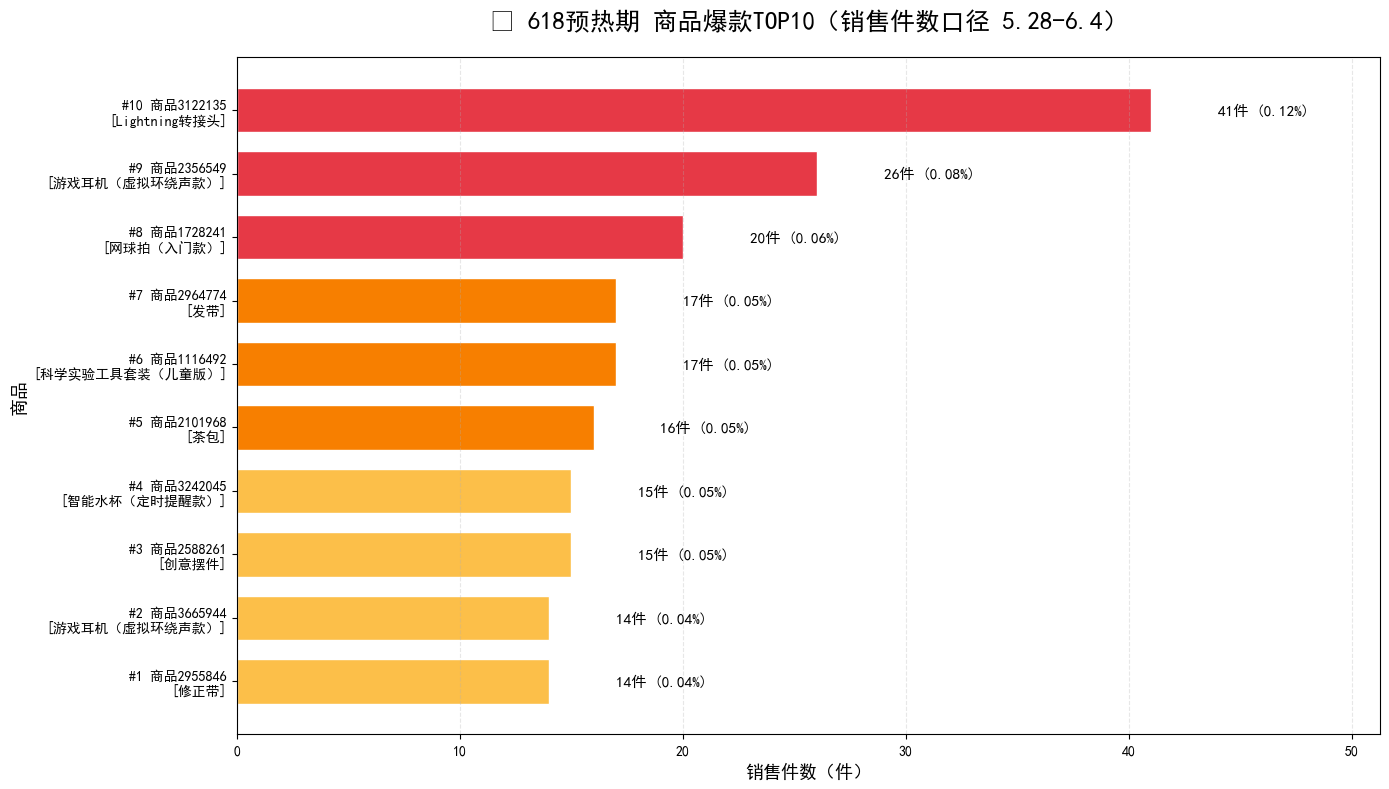


📊 补充分析（销售件数口径）

==== TOP10商品大类分布 ====
  大类  TOP10商品数
数码配件         3
家居日用         2
运动健身         1
美妆个护         1
游戏文娱         1
食品茶饮         1
文具办公         1

TOP10商品总销售件：195 件，占全平台总销售件 0.59%
第一名商品销售件：41 件，占全平台总销售件 0.12%
TOP10商品覆盖 9 个细分品类

🎉 全部完成！输出文件清单：

📦 CSV文件：
  1. 商品销量排行榜_全量.csv    —— 全商品销售件数排行
  2. 商品爆款TOP10.csv          —— TOP10商品明细（件数口径）

🖼️ 图片文件：
  3. 商品爆款TOP10.png          —— 销售件数柱状图



In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Users\ASUS\Downloads\dk"
file_path = f"{base_path}\\三表合并完整数据_带大类.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_path, encoding="utf-8-sig")
print(f"📥 读取成功，总行数：{len(df):,}")

# ============================================================
# 第一部分：商品爆款TOP10统计（口径：销售件数 sum(amount)）
# ============================================================
print("\n" + "="*60)
print("🔥 商品爆款TOP10统计")
print("="*60)

# 只取购买行为
df_buy = df[df["behavior"] == "buy"].reset_index(drop=True)
total_buy = len(df_buy)
total_amount = df_buy["amount"].sum()  # 全局总销售件数
print(f"总购买订单数：{total_buy:,}")
print(f"总销售件数：{total_amount:,} 件")
print(f"有销量的商品数：{df_buy['goods_id'].nunique():,}")

# 按商品ID聚合：销售件数、平均单价
goods_sales = df_buy.groupby("goods_id").agg(
    销售件数=("amount", "sum"),
    平均单价=("price", "mean")
).reset_index()

# 先取每个商品的品类和大类（同一个商品只取一条）
goods_info = df.drop_duplicates(subset=["goods_id"])[["goods_id", "category_label", "大类", "price"]]
# 合并商品基础信息
goods_sales = goods_sales.merge(goods_info, on="goods_id", how="left")

# 按销售件数降序排序
goods_sales = goods_sales.sort_values("销售件数", ascending=False).reset_index(drop=True)

# 计算件数占比、累计指标（分母使用总销售件数）
goods_sales["销售件占比%"] = round(goods_sales["销售件数"] / total_amount * 100, 2)
goods_sales["累计销售件"] = goods_sales["销售件数"].cumsum()
goods_sales["累计占比%"] = round(goods_sales["累计销售件"] / total_amount * 100, 2)

# 新增排名列
goods_sales.insert(0, "排名", range(1, len(goods_sales)+1))

# 截取TOP10
top10_goods = goods_sales.head(10)

print(f"\n==== 🔥 商品爆款TOP10（销售件数口径） ====")
print(top10_goods[["排名", "goods_id", "category_label", "大类", "销售件数", "销售件占比%", "平均单价"]].to_string(index=False))

# 保存完整商品销量排行CSV
goods_csv = f"{base_path}\\商品销量排行榜_全量.csv"
goods_sales.to_csv(goods_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ 全量商品销量排行已保存：商品销量排行榜_全量.csv")

# 保存TOP10 CSV
top10_csv = f"{base_path}\\商品爆款TOP10.csv"
top10_goods.to_csv(top10_csv, index=False, encoding="utf-8-sig")
print(f"✅ 商品爆款TOP10已保存：商品爆款TOP10.csv")

# ============================================================
# 第二部分：可视化 - 商品爆款TOP10柱状图
# ============================================================
print("\n" + "="*60)
print("🎨 生成商品爆款TOP10可视化图")
print("="*60)

fig, ax = plt.subplots(figsize=(14, 8))

# 横向柱状图（倒序，第一名在最上方）
y_labels = [f"#{i+1} 商品{gid}\n[{cat}]" for i, gid, cat in zip(
    range(10), top10_goods["goods_id"][::-1], top10_goods["category_label"][::-1]
)]

bars = ax.barh(y_labels, top10_goods["销售件数"][::-1], 
               color=['#E63946' if i < 3 else '#F77F00' if i < 6 else '#FCBF49' 
                      for i in range(10)][::-1],
               height=0.7, edgecolor='white', linewidth=1)

# 柱子标注：件数 + 占比
for i, bar in enumerate(bars):
    width = bar.get_width()
    rank = 10 - i
    sales = top10_goods.iloc[rank-1]["销售件数"]
    pct = top10_goods.iloc[rank-1]["销售件占比%"]
    ax.text(width + 3, bar.get_y() + bar.get_height()/2.,
            f'{sales}件 ({pct}%)', 
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_title('🔥 618预热期 商品爆款TOP10（销售件数口径 5.28-6.4）', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('销售件数（件）', fontsize=13)
ax.set_ylabel('商品', fontsize=13)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# X轴预留文字空间
ax.set_xlim(0, top10_goods["销售件数"].max() * 1.25)

plt.tight_layout()

# 保存图片
top10_png = f"{base_path}\\商品爆款TOP10.png"
plt.savefig(top10_png, dpi=200, bbox_inches='tight')
print(f"✅ 商品爆款TOP10图已保存：商品爆款TOP10.png")
plt.show()

# ============================================================
# 第三部分：补充分析
# ============================================================
print("\n" + "="*60)
print("📊 补充分析（销售件数口径）")
print("="*60)

# TOP10商品大类分布
top10_category = top10_goods["大类"].value_counts().reset_index()
top10_category.columns = ["大类", "TOP10商品数"]
print(f"\n==== TOP10商品大类分布 ====")
print(top10_category.to_string(index=False))

# TOP10总销售件、占比
top10_total = top10_goods["销售件数"].sum()
top10_pct = top10_total / total_amount * 100
print(f"\nTOP10商品总销售件：{top10_total} 件，占全平台总销售件 {top10_pct:.2f}%")

# 单品头部
top1_total = top10_goods.iloc[0]["销售件数"]
top1_pct = top1_total / total_amount * 100
print(f"第一名商品销售件：{top1_total} 件，占全平台总销售件 {top1_pct:.2f}%")

# 细品类覆盖数量
top10_cat_count = top10_goods["category_label"].nunique()
print(f"TOP10商品覆盖 {top10_cat_count} 个细分品类")

print("\n" + "="*60)
print("🎉 全部完成！输出文件清单：")
print("="*60)
print("""
📦 CSV文件：
  1. 商品销量排行榜_全量.csv    —— 全商品销售件数排行
  2. 商品爆款TOP10.csv          —— TOP10商品明细（件数口径）

🖼️ 图片文件：
  3. 商品爆款TOP10.png          —— 销售件数柱状图
""")